# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import product
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
df = pd.read_csv("minuman.csv")
df.head(20)


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
5,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,9.09,2,0.00,18.18,Schleswig-Holstein,2023-03-16
6,ORD3,CUS1806,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20
7,ORD3,CUS1806,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20
8,ORD3,CUS1806,B2B,San Pellegrino,Water,1.21,92,0.10,100.19,Hamburg,2022-11-20
9,ORD3,CUS1806,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353003 entries, 0 to 353002
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       353003 non-null  object 
 1   Customer_ID    353003 non-null  object 
 2   Customer_Type  353003 non-null  object 
 3   Product        353003 non-null  object 
 4   Category       353003 non-null  object 
 5   Unit_Price     353003 non-null  float64
 6   Quantity       353003 non-null  int64  
 7   Discount       353003 non-null  float64
 8   Total_Price    353003 non-null  float64
 9   Region         353003 non-null  object 
 10  Order_Date     353003 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 29.6+ MB
0
Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int

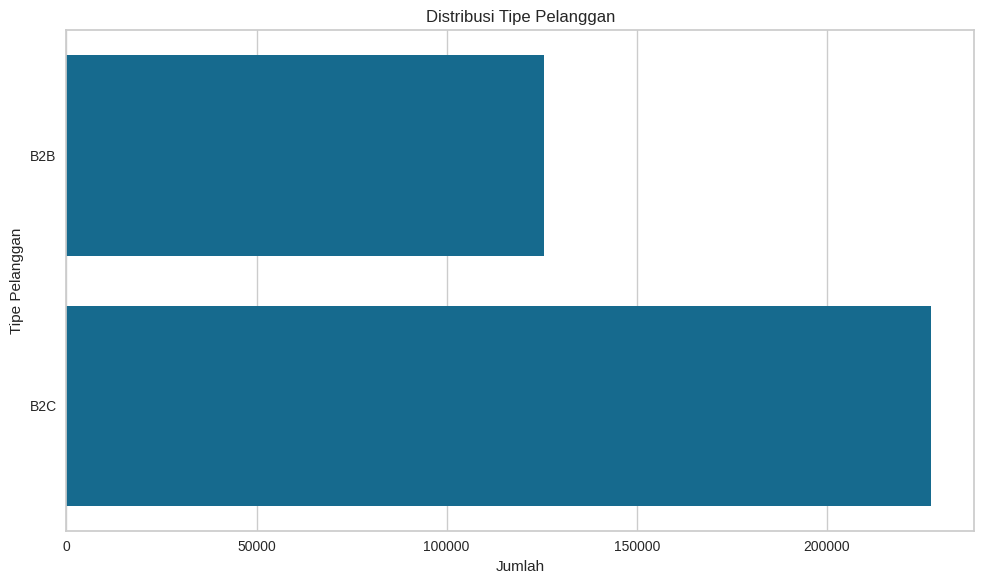

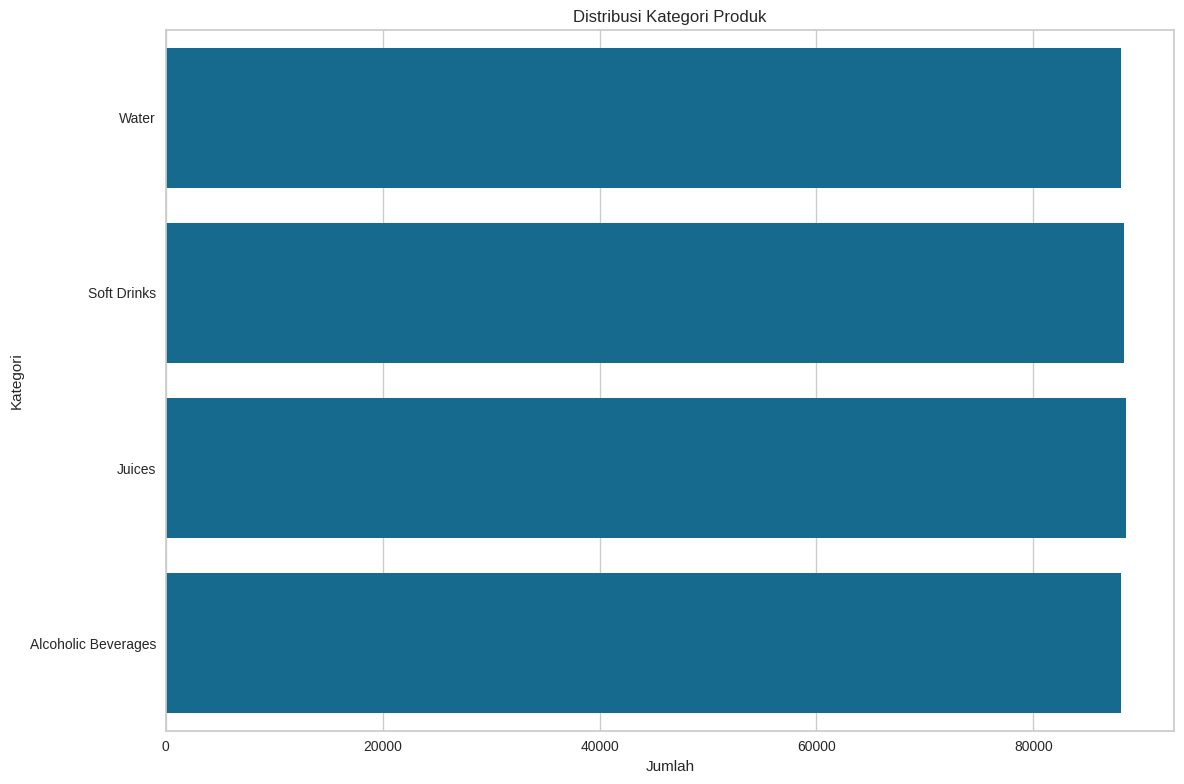

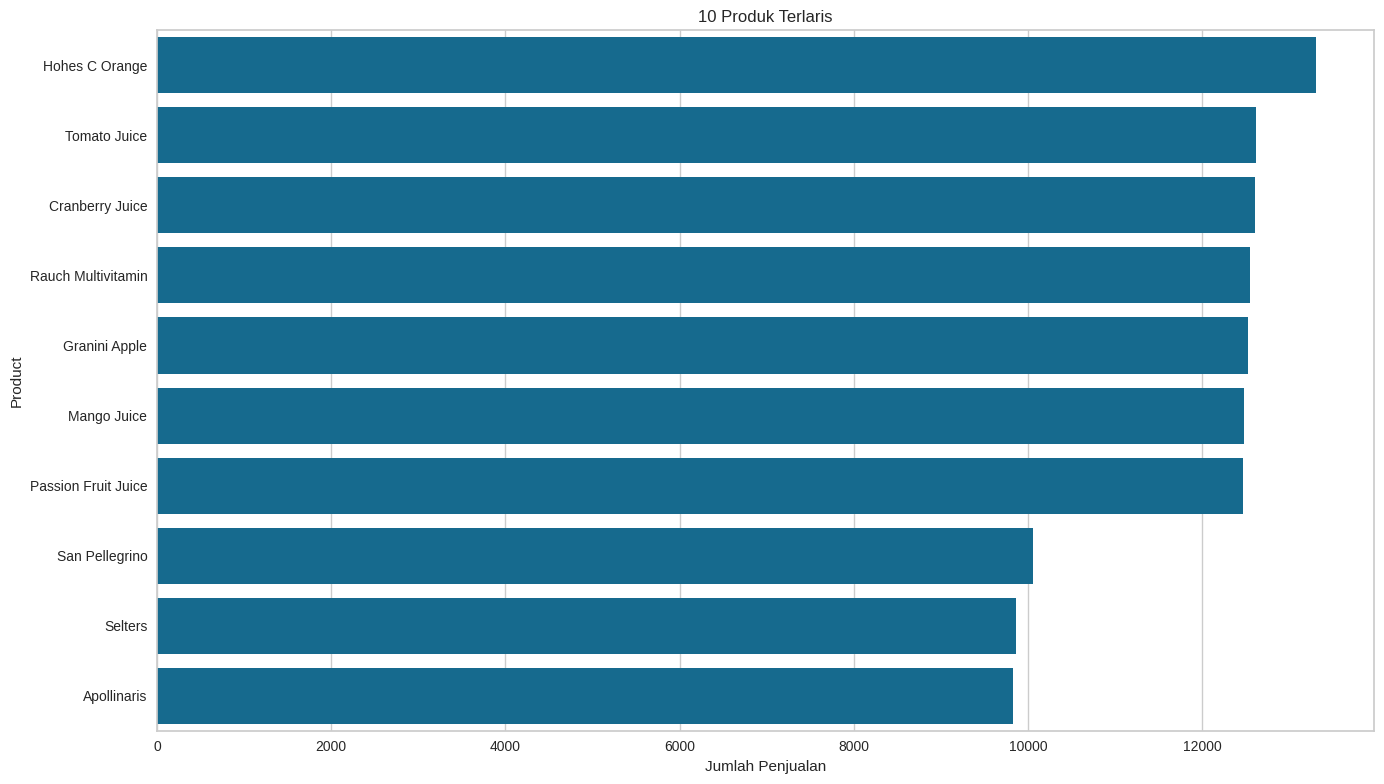

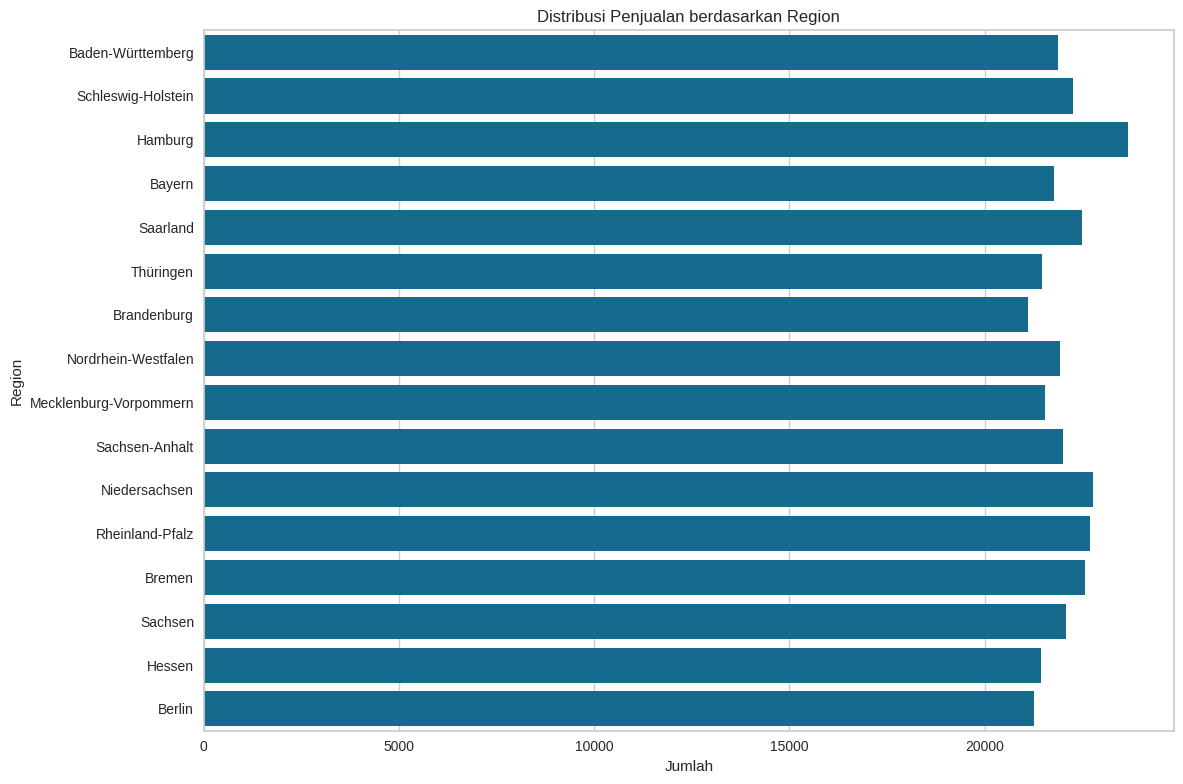

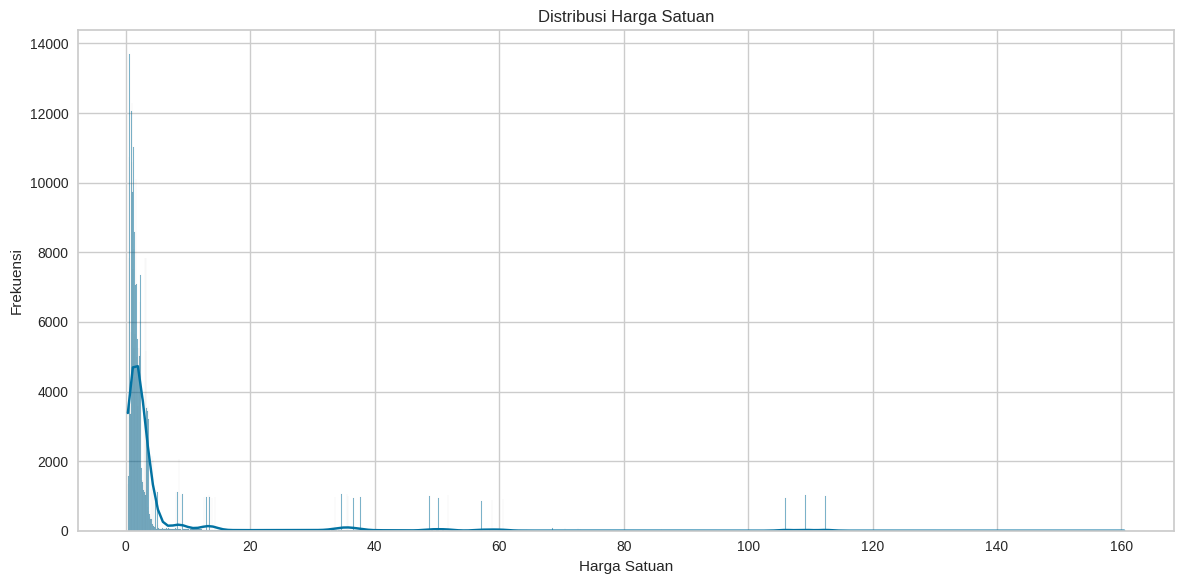

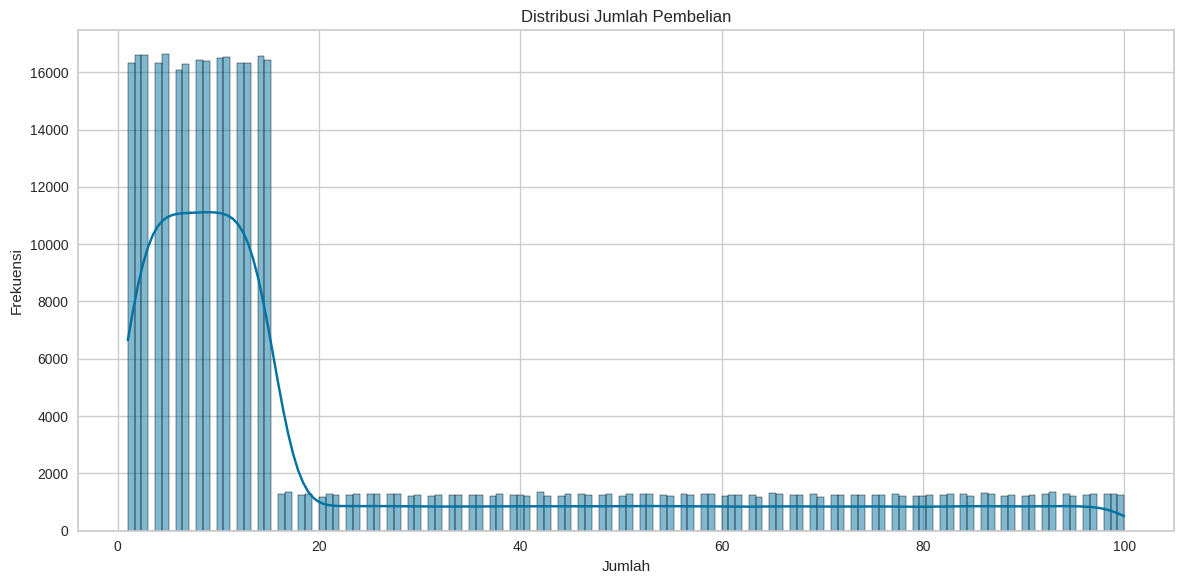

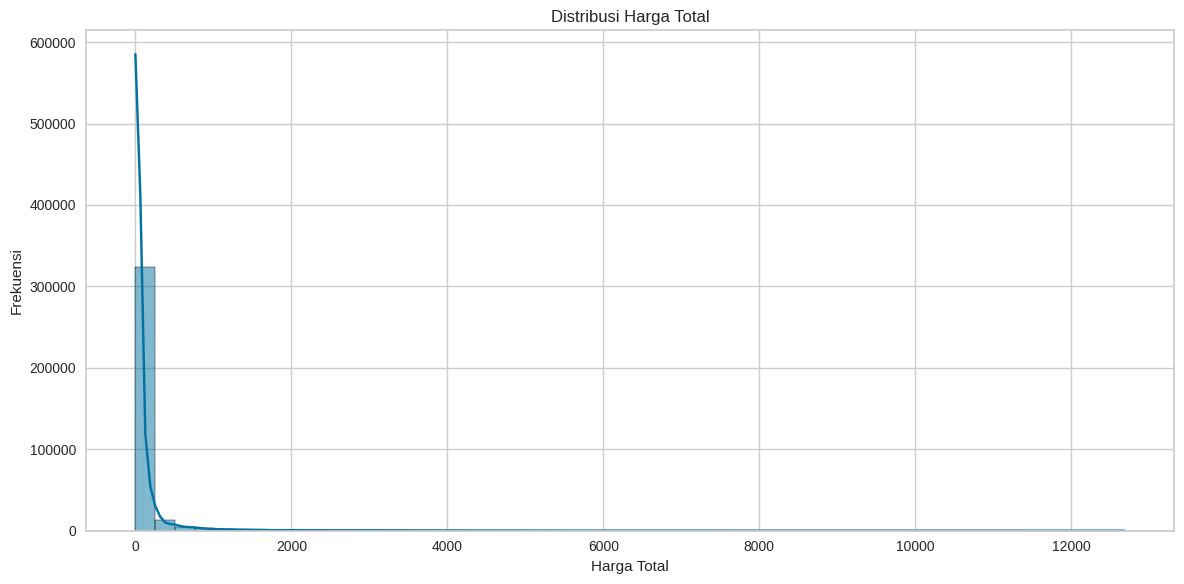

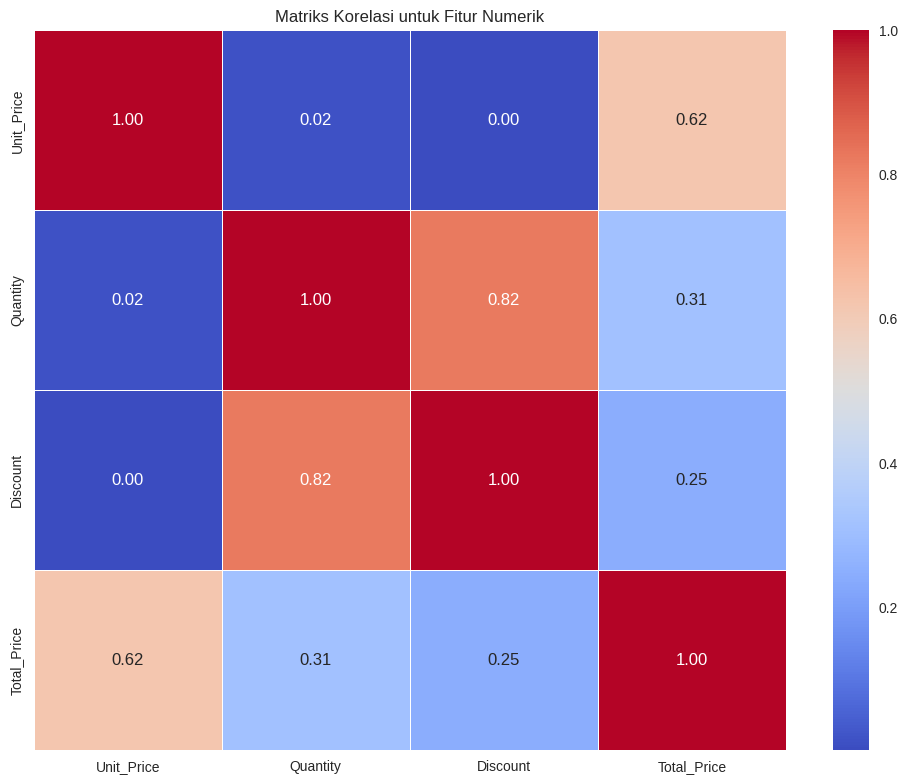

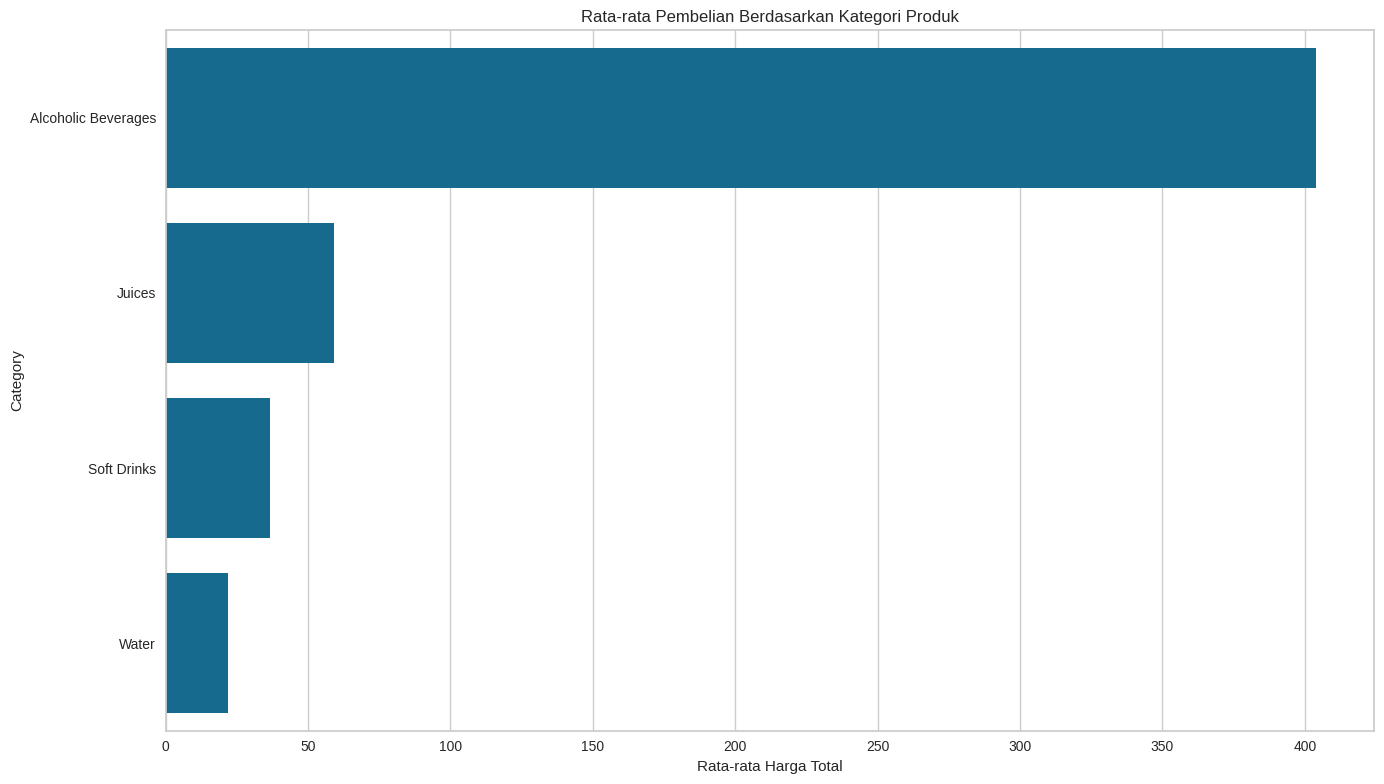

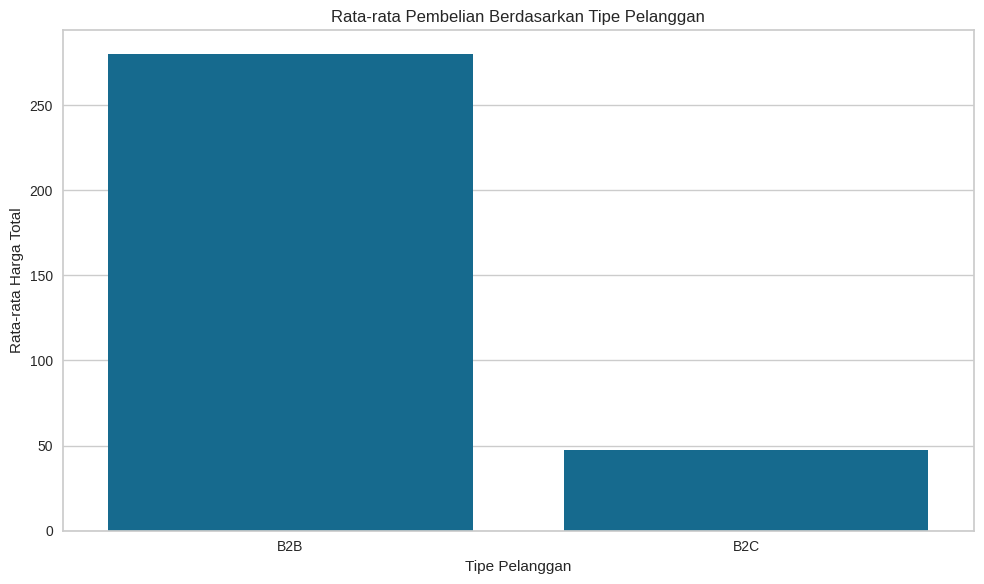

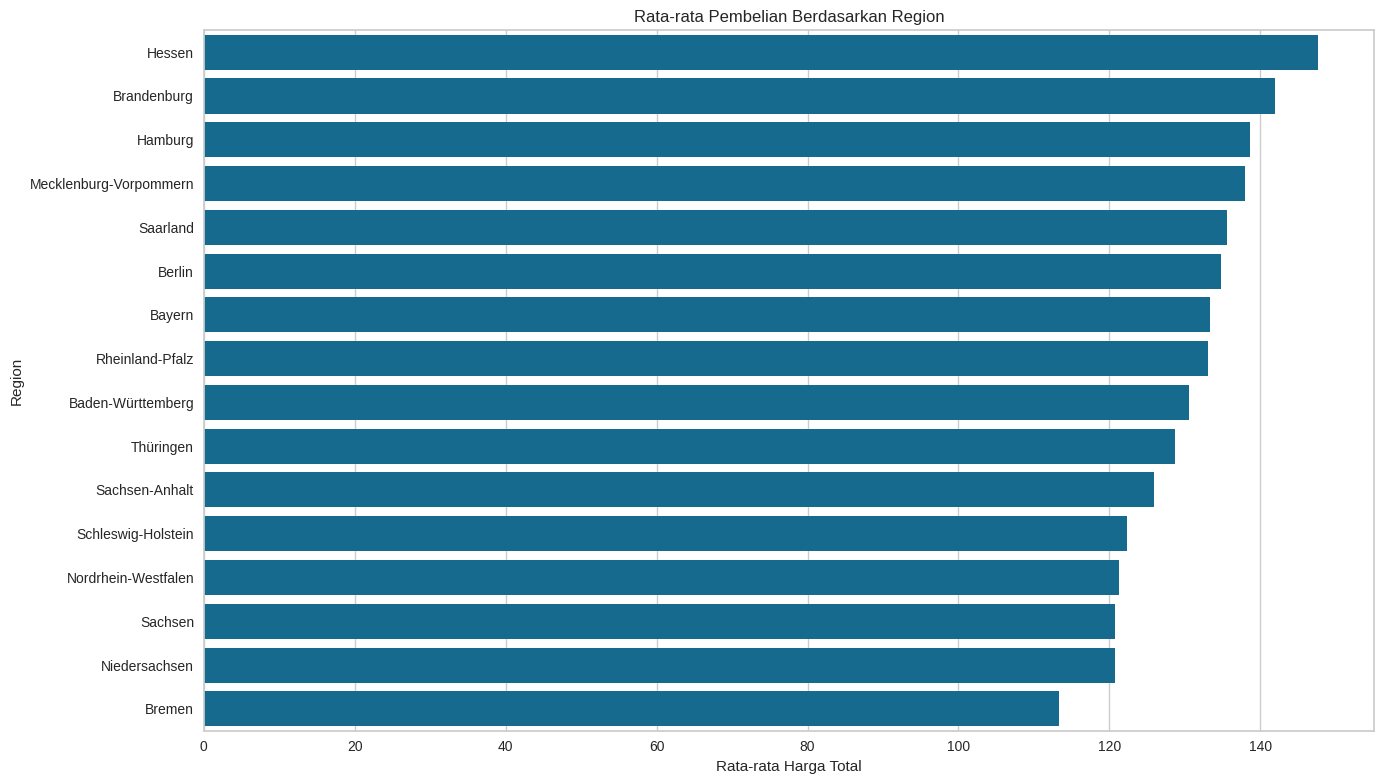

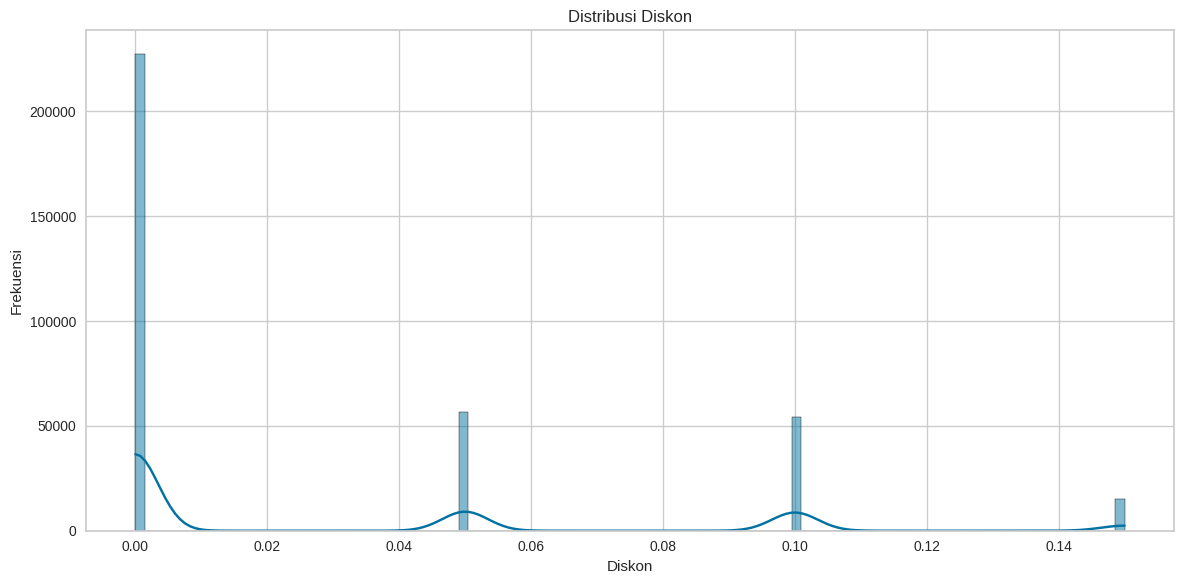

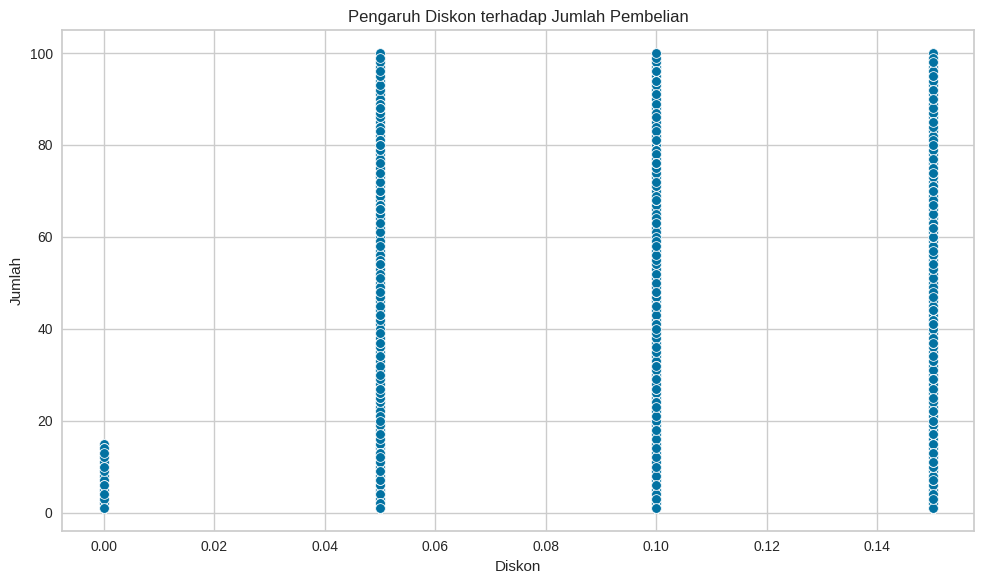

In [3]:
print("\nInformasi Dataset:")
df.info()
print(df.duplicated().sum())
print(df.isna().sum())

print("\nStatistik deskriptif untuk fitur numerik:")
print(df.describe())

print("\nDistribusi Customer Type:")
customer_type_counts = df['Customer_Type'].value_counts()
print(customer_type_counts)

print("\nDistribusi Category:")
category_counts = df['Category'].value_counts()
print(category_counts)

print("\nDistribusi Region:")
region_counts = df['Region'].value_counts()
print(region_counts)

# 6. Visualisasi
# Distribusi Customer Type
plt.figure(figsize=(10, 6))
sns.countplot(y='Customer_Type', data=df)
plt.title('Distribusi Tipe Pelanggan')
plt.xlabel('Jumlah')
plt.ylabel('Tipe Pelanggan')
plt.tight_layout()
plt.show()

# Distribusi Category
plt.figure(figsize=(12, 8))
sns.countplot(y='Category', data=df)
plt.title('Distribusi Kategori Produk')
plt.xlabel('Jumlah')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

# Top 10 Products
top_products = df['Product'].value_counts().head(10)
plt.figure(figsize=(14, 8))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('10 Produk Terlaris')
plt.xlabel('Jumlah Penjualan')
plt.tight_layout()
plt.show()

# Distribusi Region
plt.figure(figsize=(12, 8))
sns.countplot(y='Region', data=df)
plt.title('Distribusi Penjualan berdasarkan Region')
plt.xlabel('Jumlah')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# Histogram untuk Unit Price
plt.figure(figsize=(12, 6))
sns.histplot(df['Unit_Price'], kde=True)
plt.title('Distribusi Harga Satuan')
plt.xlabel('Harga Satuan')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Histogram untuk Quantity
plt.figure(figsize=(12, 6))
sns.histplot(df['Quantity'], kde=True)
plt.title('Distribusi Jumlah Pembelian')
plt.xlabel('Jumlah')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Histogram untuk Total Price
plt.figure(figsize=(12, 6))
sns.histplot(df['Total_Price'], kde=True, bins=50)
plt.title('Distribusi Harga Total')
plt.xlabel('Harga Total')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Matriks korelasi untuk fitur numerik
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Unit_Price', 'Quantity', 'Discount', 'Total_Price']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi untuk Fitur Numerik')
plt.tight_layout()
plt.show()

# Rata-rata pembelian berdasarkan kategori produk
plt.figure(figsize=(14, 8))
category_avg = df.groupby('Category')['Total_Price'].mean().sort_values(ascending=False)
sns.barplot(x=category_avg.values, y=category_avg.index)
plt.title('Rata-rata Pembelian Berdasarkan Kategori Produk')
plt.xlabel('Rata-rata Harga Total')
plt.tight_layout()
plt.show()

# Rata-rata pembelian berdasarkan tipe pelanggan
plt.figure(figsize=(10, 6))
customer_type_avg = df.groupby('Customer_Type')['Total_Price'].mean().sort_values(ascending=False)
sns.barplot(x=customer_type_avg.index, y=customer_type_avg.values)
plt.title('Rata-rata Pembelian Berdasarkan Tipe Pelanggan')
plt.xlabel('Tipe Pelanggan')
plt.ylabel('Rata-rata Harga Total')
plt.tight_layout()
plt.show()

# Rata-rata pembelian berdasarkan region
plt.figure(figsize=(14, 8))
region_avg = df.groupby('Region')['Total_Price'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.values, y=region_avg.index)
plt.title('Rata-rata Pembelian Berdasarkan Region')
plt.xlabel('Rata-rata Harga Total')
plt.tight_layout()
plt.show()

# Distribusi Diskon
plt.figure(figsize=(12, 6))
sns.histplot(df['Discount'], kde=True)
plt.title('Distribusi Diskon')
plt.xlabel('Diskon')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Pengaruh diskon terhadap jumlah pembelian
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Quantity', data=df)
plt.title('Pengaruh Diskon terhadap Jumlah Pembelian')
plt.xlabel('Diskon')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()



# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [4]:
df_processed = df.copy()
df2 = df.drop(columns=['Order_ID', 'Customer_ID', 'Order_Date'])

df2.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg
1,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg
2,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg
3,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg


Handling Missing Values:
Missing values before: 0
Missing values after: 0
Handling Duplicate Rows:
Duplicate rows before: 0
Handling Outliers:
Outliers in Unit_Price: 42997 (12.18%)


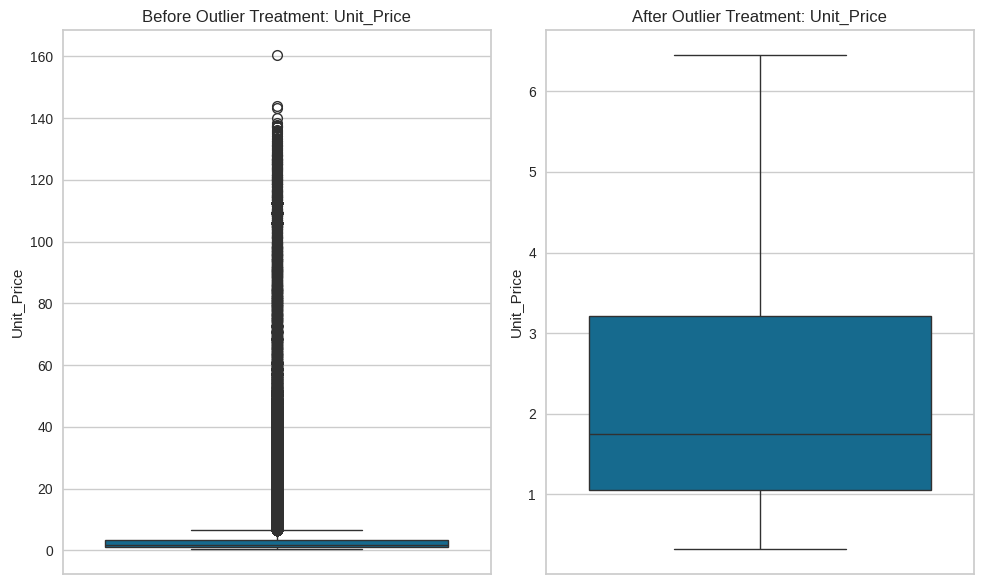

Outliers in Quantity: 42574 (12.06%)


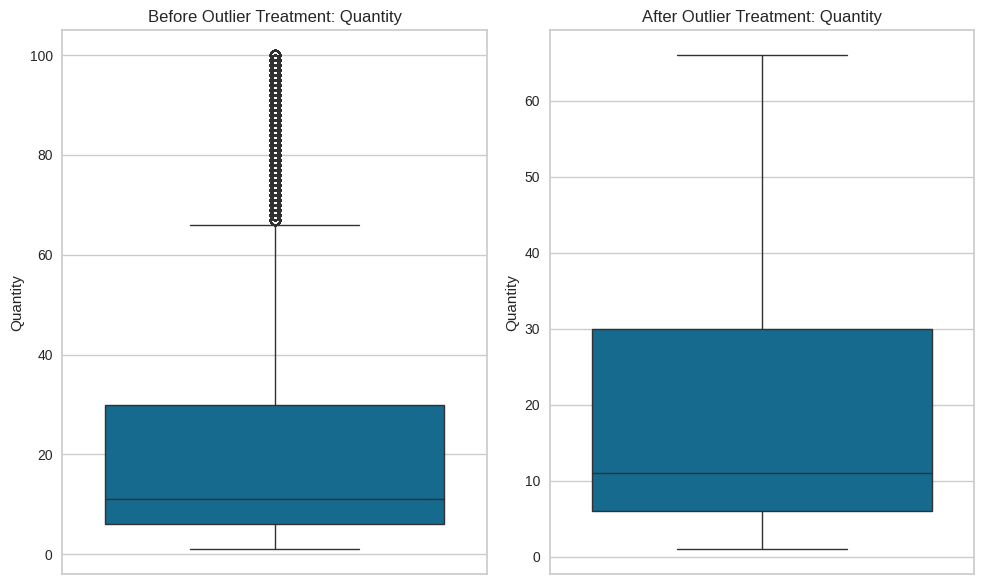

Outliers in Discount: 15040 (4.26%)


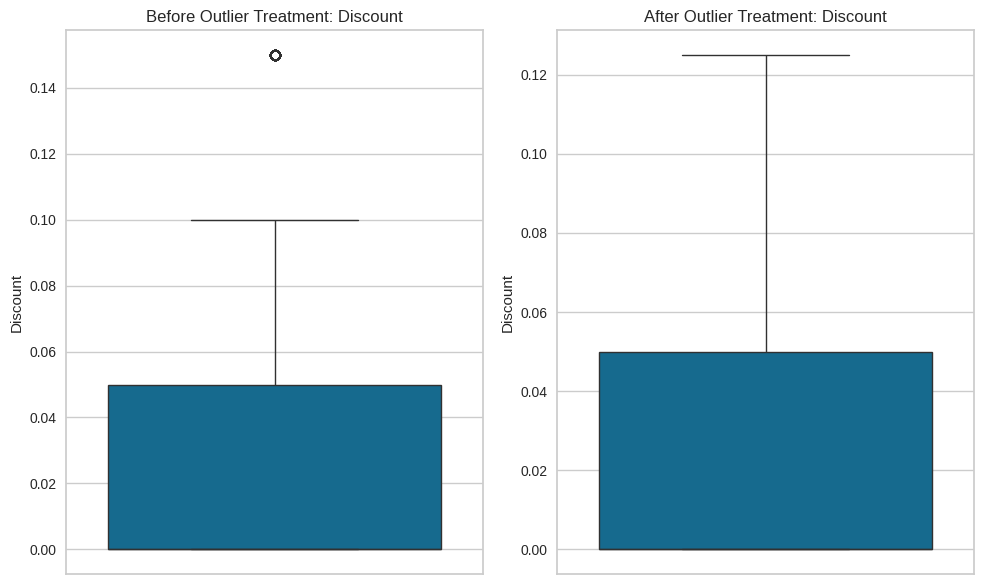

Outliers in Total_Price: 45801 (12.97%)


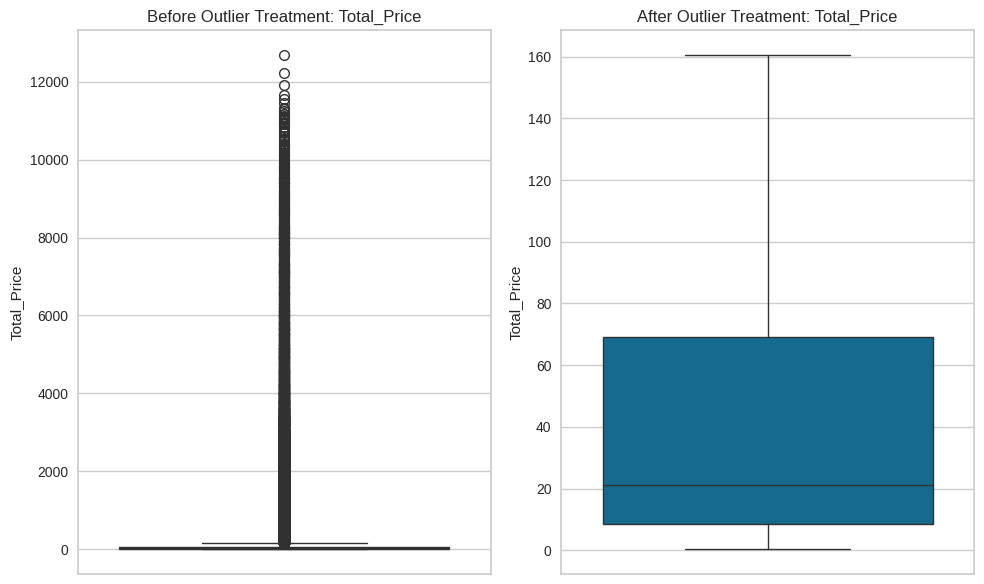

Encoding Categorical Variables:
Encoding Customer_Type (unique values: 2)
Encoding Product (unique values: 47)
Encoding Category (unique values: 4)
Scaling Numerical Features:
Numerical features have been standardized

Before standardization:
       Unit_Price   Quantity   Discount  Total_Price
count   353003.00  353003.00  353003.00    353003.00
mean         2.40      20.98       0.03        47.83
std          1.81      22.07       0.04        54.55
min          0.32       1.00       0.00         0.30
25%          1.05       6.00       0.00         8.40
50%          1.75      11.00       0.00        21.15
75%          3.21      30.00       0.05        69.26
max          6.45      66.00       0.12       160.55

After standardization:
       Unit_Price   Quantity   Discount  Total_Price
count   353003.00  353003.00  353003.00    353003.00
mean         0.00      -0.00       0.00         0.00
std          1.00       1.00       1.00         1.00
min         -1.15      -0.91      -0.68     

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Customer_Type_Encoded,Product_Encoded,Category_Encoded
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53.0,0.10,79.18,Baden-Württemberg,2023-08-23,0,42,3
1,ORD1,CUS1496,B2B,Evian,Water,1.56,66.0,0.10,126.36,Baden-Württemberg,2023-08-23,0,9,3
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,66.0,0.05,81.14,Baden-Württemberg,2023-08-23,0,38,2
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59.0,0.10,160.55,Baden-Württemberg,2023-08-23,0,29,1
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35.0,0.10,27.40,Baden-Württemberg,2023-08-23,0,12,3


In [5]:
#X = df_processed
#print(X.isnull().sum())
#X = X.dropna()

print("Handling Missing Values:")
missing_before = df_processed.isnull().sum().sum()
print(f"Missing values before: {missing_before}")

if missing_before > 0:
    for col in df_processed.select_dtypes(include=['int64', 'float64']).columns:
        if df_processed[col].isnull().sum() > 0:
            median_value = df_processed[col].median()
            print(f"Filling missing values in {col} with median: {median_value}")
            df_processed[col] = df_processed[col].fillna(median_value)

    for col in df_processed.select_dtypes(include=['object']).columns:
        if df_processed[col].isnull().sum() > 0:
            mode_value = df_processed[col].mode()[0]
            print(f"Filling missing values in {col} with mode: {mode_value}")
            df_processed[col] = df_processed[col].fillna(mode_value)

missing_after = df_processed.isnull().sum().sum()
print(f"Missing values after: {missing_after}")

print("Handling Duplicate Rows:")
duplicates_before = df_processed.duplicated().sum()
print(f"Duplicate rows before: {duplicates_before}")

if duplicates_before > 0:
    df_processed.drop_duplicates(inplace=True)
    print(f"Duplicate rows after: {df_processed.duplicated().sum()}")


print("Handling Outliers:")
numerical_cols = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']

for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)).sum()
    outliers_percentage = (outliers_count / len(df_processed)) * 100
    print(f"Outliers in {col}: {outliers_count} ({outliers_percentage:.2f}%)")

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_processed[col])
    plt.title(f'Before Outlier Treatment: {col}')

    df_processed[col] = np.where(df_processed[col] < lower_bound, lower_bound, df_processed[col])
    df_processed[col] = np.where(df_processed[col] > upper_bound, upper_bound, df_processed[col])

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_processed[col])
    plt.title(f'After Outlier Treatment: {col}')
    plt.tight_layout()
    plt.show()

print("Encoding Categorical Variables:")
categorical_cols = ['Customer_Type', 'Product', 'Category']
label_encoders = {}

for col in categorical_cols:
    if col in df_processed.columns:
        print(f"Encoding {col} (unique values: {df_processed[col].nunique()})")
        le = LabelEncoder()
        df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le

print("Scaling Numerical Features:")
numerical_features = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']

df_normalized = df_processed.copy()
scaler = StandardScaler()
df_normalized[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

print("Numerical features have been standardized")
print("\nBefore standardization:")
print(df_processed[numerical_features].describe().round(2))

print("\nAfter standardization:")
print(df_normalized[numerical_features].describe().round(2))

df_original = df.copy()  # Original data
df_processed_final = df_processed.copy()
df_normalized_final = df_normalized.copy()

print("\nFinal Data Shapes:")
print(f"Original data: {df_original.shape}")
print(f"Processed data (without scaling): {df_processed_final.shape}")
print(f"Normalized data (with scaling): {df_normalized_final.shape}")

print("\nProcessed Data Sample:")
df_processed.head()

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

Preparing data for clustering...
Features used for clustering: ['Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Customer_Type_Encoded', 'Product_Encoded', 'Category_Encoded']
Data shape: (353003, 7)

Using a random sample of 500 data points for metrics calculation

Determining optimal number of clusters...

Evaluating different numbers of clusters:
For n_clusters = 2:
  - Silhouette Score: 0.683
For n_clusters = 3:
  - Silhouette Score: 0.566
For n_clusters = 4:
  - Silhouette Score: 0.555


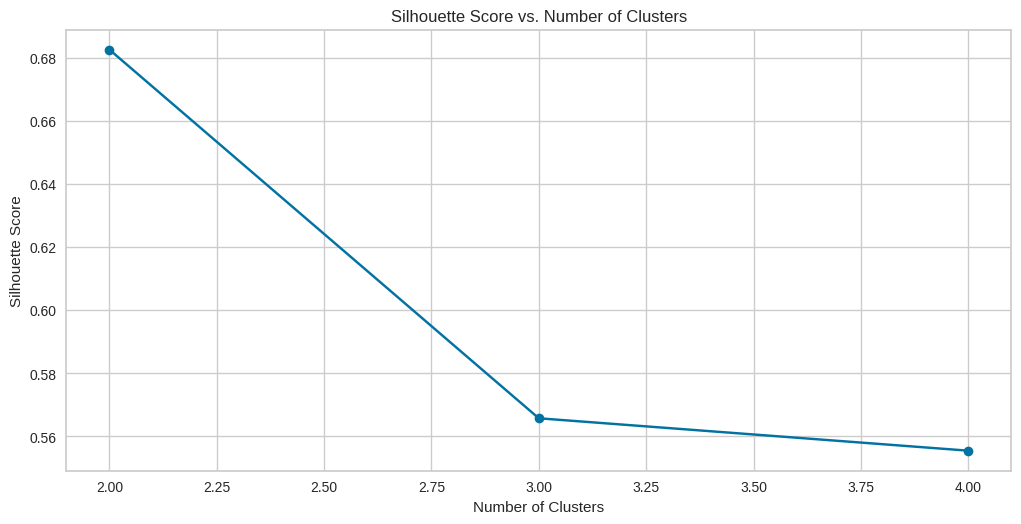


Optimal number of clusters:
Silhouette Score: 2 clusters


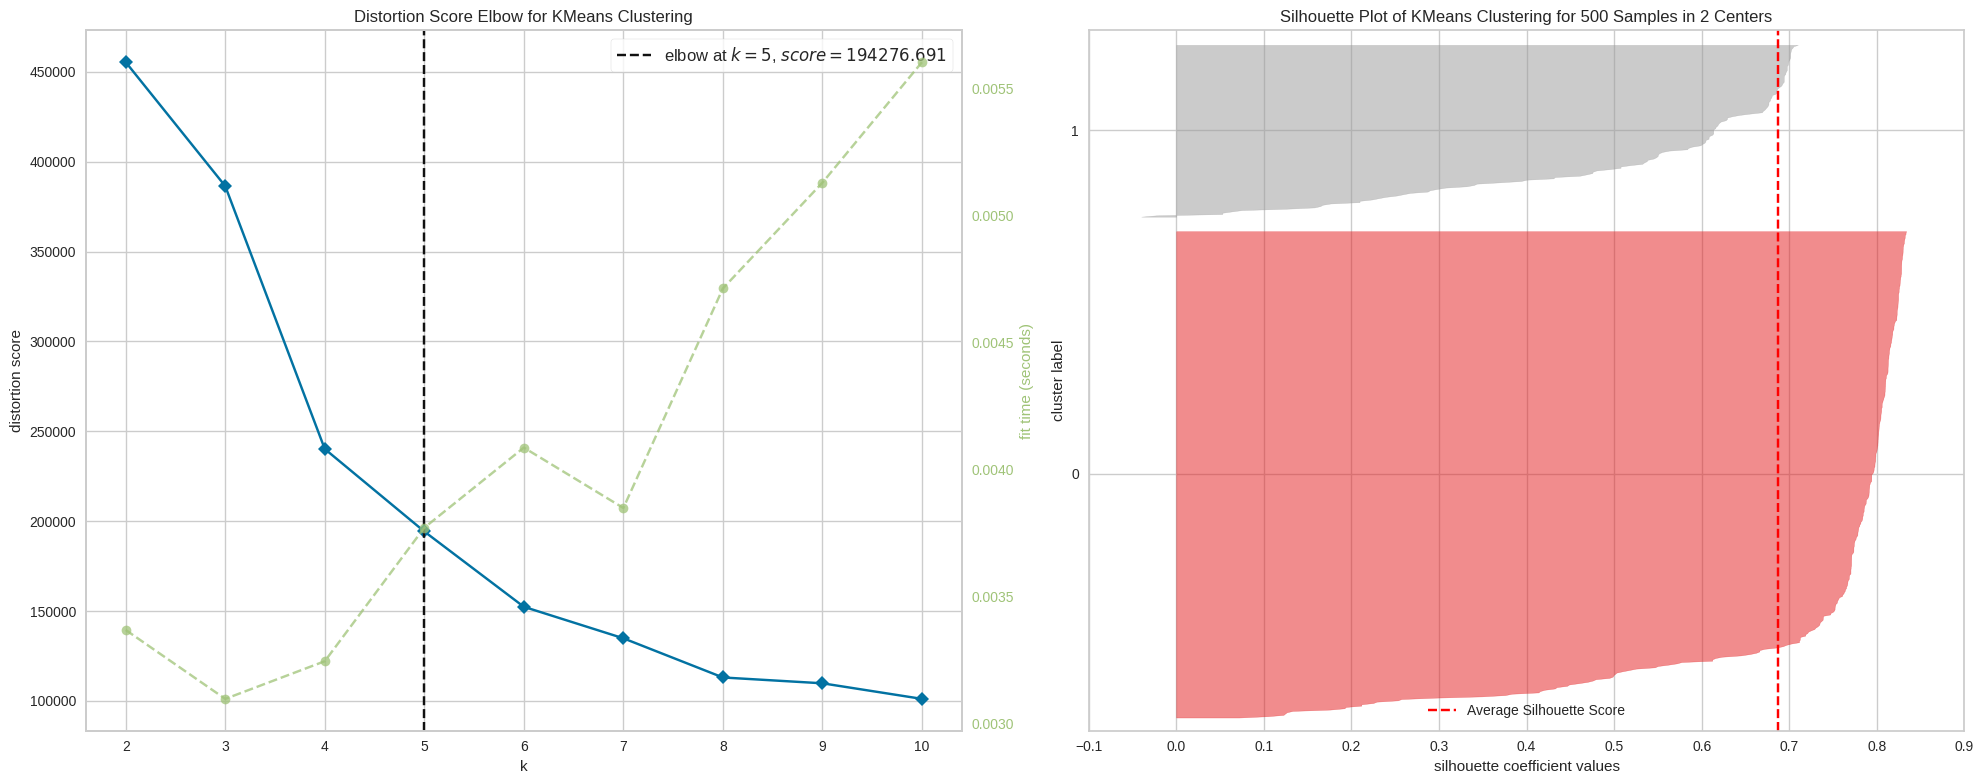


Final selected optimal number of clusters: 2
Preparing data for clustering...
Features used for clustering: ['Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Customer_Type_Encoded', 'Product_Encoded', 'Category_Encoded']
Data shape: (353003, 7)

Using a random sample of 500 data points for metrics calculation

Determining optimal number of clusters...

Evaluating different numbers of clusters:
For n_clusters = 2:
  - Silhouette Score: 0.683
For n_clusters = 3:
  - Silhouette Score: 0.566
For n_clusters = 4:
  - Silhouette Score: 0.555


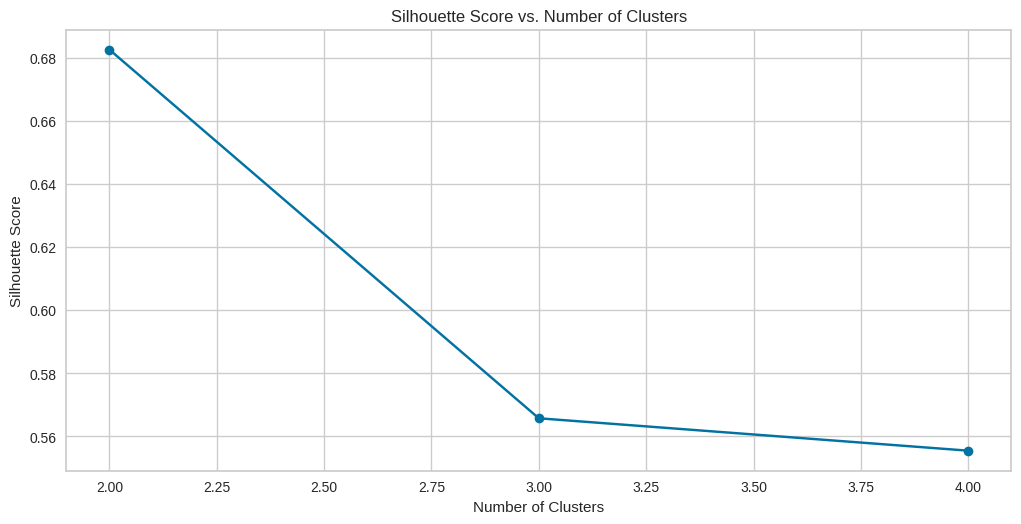


Optimal number of clusters:
Silhouette Score: 2 clusters


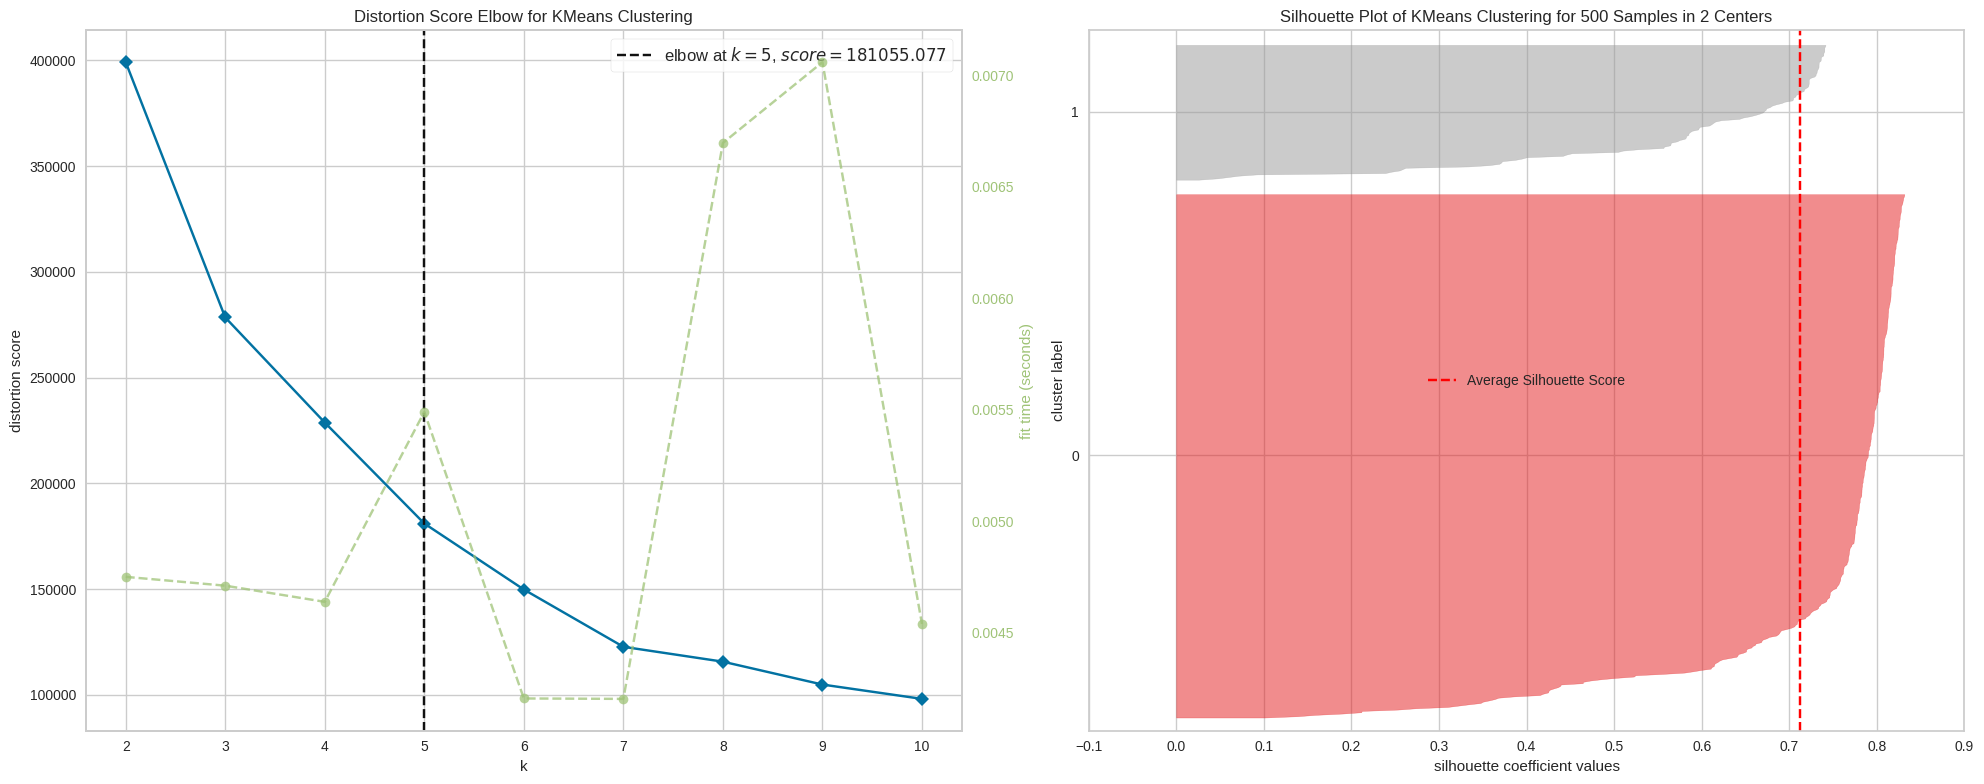


Final selected optimal number of clusters: 2

Building final KMeans model...
Cluster distribution:
Cluster
0.0     85264
1.0    267739
Name: count, dtype: int64

Visualizing clusters using PCA...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


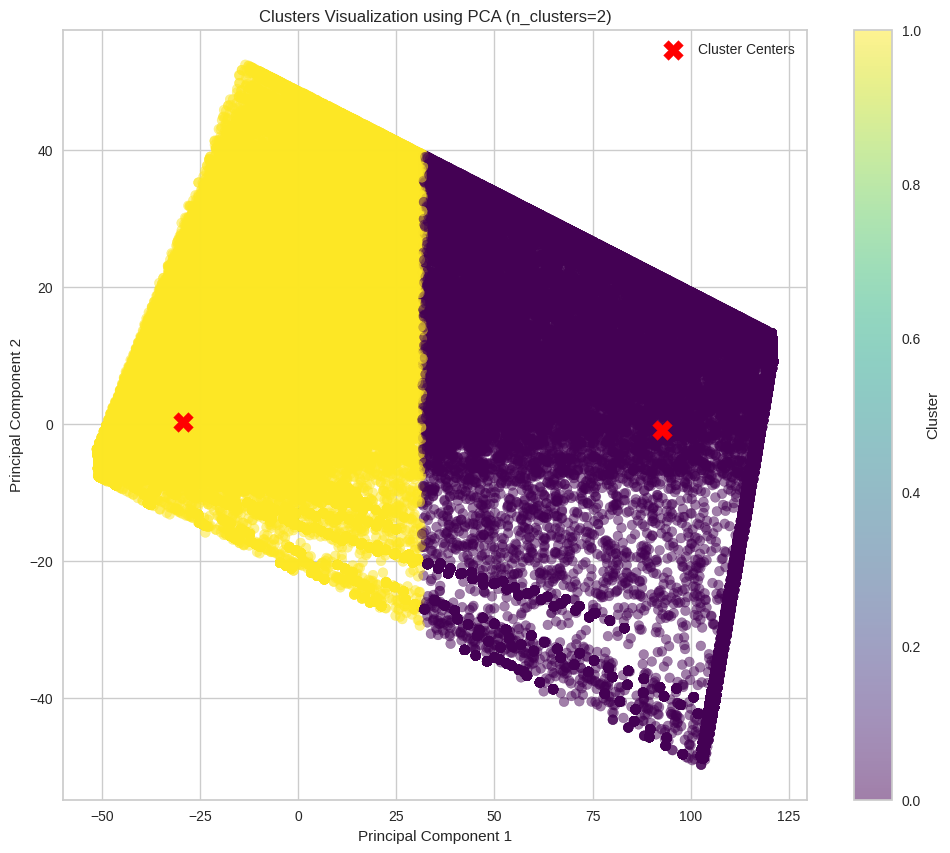


Trying other clustering algorithms for comparison...

DBSCAN Clustering:
DBSCAN couldn't form proper clusters with current parameters.
Number of clusters: 0
Noise points: 500

Hierarchical Clustering:
Silhouette Score: 0.700


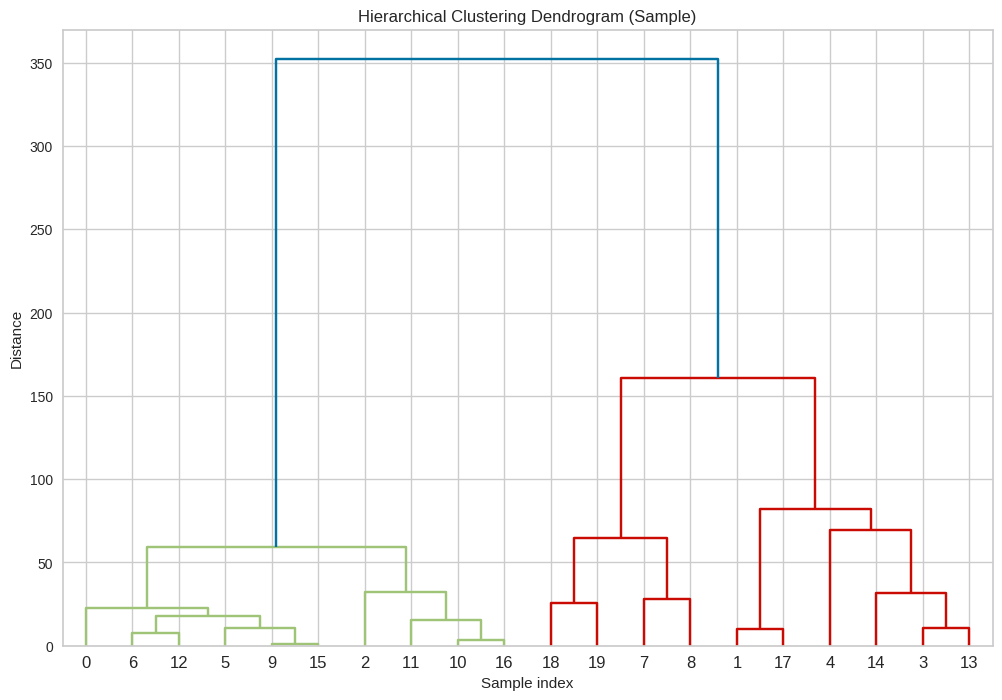

Cluster distribution:
Cluster
0.0     85264
1.0    267739
Name: count, dtype: int64

Visualizing clusters using PCA...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


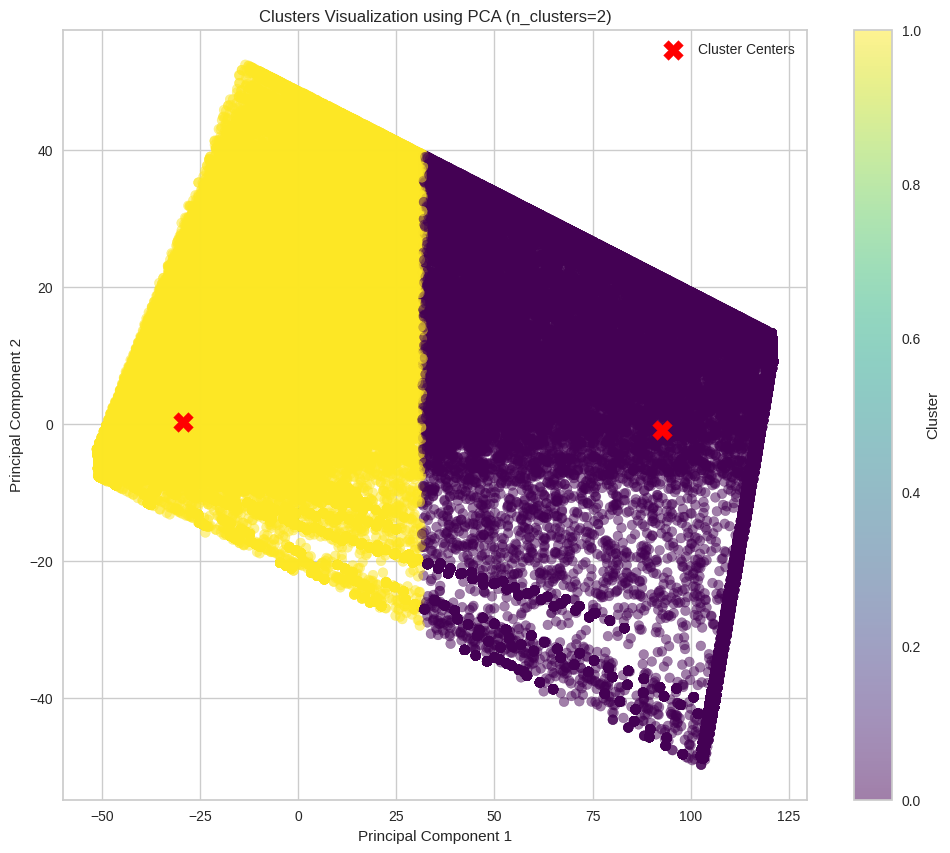


Trying other clustering algorithms for comparison...

DBSCAN Clustering:
DBSCAN couldn't form proper clusters with current parameters.
Number of clusters: 0
Noise points: 500

Hierarchical Clustering:
Silhouette Score: 0.700


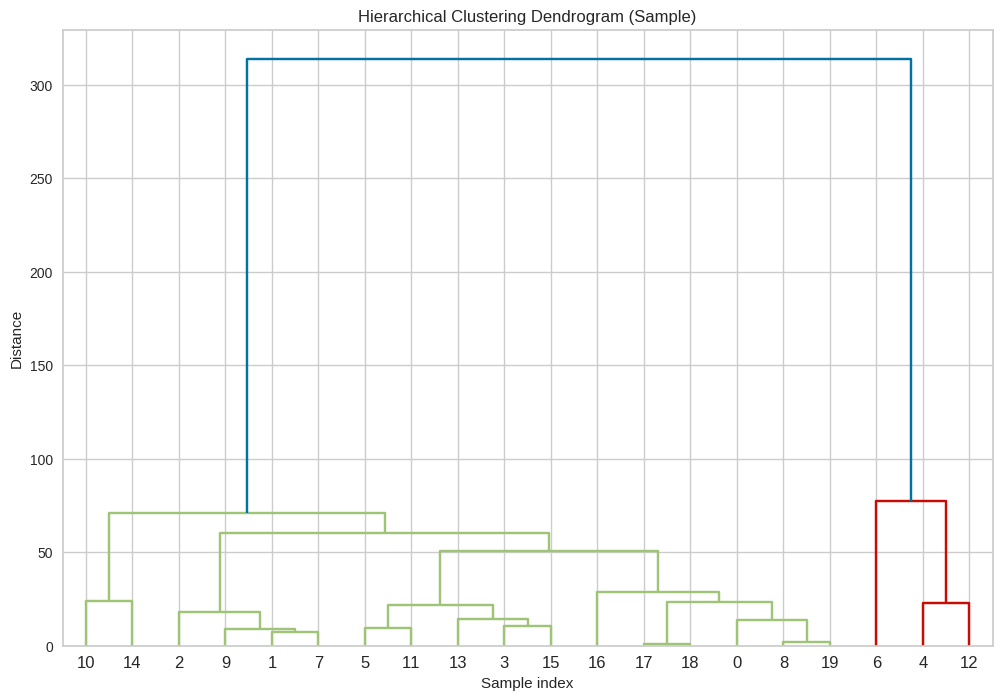

In [6]:
X = df_processed.head(2500).copy()

print("Preparing data for clustering...")
X_numeric = df_processed.select_dtypes(include=['int64', 'float64']).copy()

columns_to_exclude = ['Order_ID', 'Customer_ID']
X = X_numeric.copy()
for col in columns_to_exclude:
    if col in X.columns:
        X = X.drop(col, axis=1)

print(f"Features used for clustering: {X.columns.tolist()}")
print(f"Data shape: {X.shape}")

MAX_SAMPLE_SIZE = 500
sample_size = min(MAX_SAMPLE_SIZE, len(X))
if sample_size < len(X):
    print(f"\nUsing a random sample of {sample_size} data points for metrics calculation")
    sample_indices = random.sample(range(len(X)), sample_size)
    X_sample = X.iloc[sample_indices]
else:
    X_sample = X

print("\nDetermining optimal number of clusters...")
range_n_clusters = range(2, 5)

silhouette_scores = []

print("\nEvaluating different numbers of clusters:")
for n_clusters in range_n_clusters:
    # Create KMeans model
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels, sample_size=500, random_state=42)

    silhouette_scores.append(silhouette_avg)

    print(f"For n_clusters = {n_clusters}:")
    print(f"  - Silhouette Score: {silhouette_avg:.3f}")

plt.figure(figsize=(20, 10))

# Silhouette Score plot
plt.subplot(2, 2, 1)
plt.plot(range_n_clusters, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_silhouette = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]

print("\nOptimal number of clusters:")
print(f"Silhouette Score: {optimal_silhouette} clusters")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

visualizer = KElbowVisualizer(KMeans(random_state=42), k=range(2, 11), ax=ax1)
visualizer.fit(X_sample)  # Use sample data here
visualizer.finalize()

visualizer = SilhouetteVisualizer(
    KMeans(n_clusters=optimal_silhouette, random_state=42),
    ax=ax2
)
visualizer.fit(X_sample)  # Use sample data here
visualizer.finalize()

plt.tight_layout()
plt.show()

final_optimal_clusters = 2  # You can adjust this based on visualizations
print(f"\nFinal selected optimal number of clusters: {final_optimal_clusters}")

X = df_processed.head(2500).copy()

print("Preparing data for clustering...")
X_numeric = df_processed.select_dtypes(include=['int64', 'float64']).copy()

columns_to_exclude = ['Order_ID', 'Customer_ID']
X = X_numeric.copy()
for col in columns_to_exclude:
    if col in X.columns:
        X = X.drop(col, axis=1)

print(f"Features used for clustering: {X.columns.tolist()}")
print(f"Data shape: {X.shape}")

MAX_SAMPLE_SIZE = 500
sample_size = min(MAX_SAMPLE_SIZE, len(X))
if sample_size < len(X):
    print(f"\nUsing a random sample of {sample_size} data points for metrics calculation")
    sample_indices = random.sample(range(len(X)), sample_size)
    X_sample = X.iloc[sample_indices]
else:
    X_sample = X

print("\nDetermining optimal number of clusters...")
range_n_clusters = range(2, 5)

silhouette_scores = []

print("\nEvaluating different numbers of clusters:")
for n_clusters in range_n_clusters:
    # Create KMeans model
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels, sample_size=500, random_state=42)

    silhouette_scores.append(silhouette_avg)

    print(f"For n_clusters = {n_clusters}:")
    print(f"  - Silhouette Score: {silhouette_avg:.3f}")

plt.figure(figsize=(20, 10))

# Silhouette Score plot
plt.subplot(2, 2, 1)
plt.plot(range_n_clusters, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_silhouette = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]

print("\nOptimal number of clusters:")
print(f"Silhouette Score: {optimal_silhouette} clusters")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

visualizer = KElbowVisualizer(KMeans(random_state=42), k=range(2, 11), ax=ax1)
visualizer.fit(X_sample)  # Use sample data here
visualizer.finalize()

visualizer = SilhouetteVisualizer(
    KMeans(n_clusters=optimal_silhouette, random_state=42),
    ax=ax2
)
visualizer.fit(X_sample)  # Use sample data here
visualizer.finalize()

plt.tight_layout()
plt.show()

final_optimal_clusters = 2  # You can adjust this based on visualizations
print(f"\nFinal selected optimal number of clusters: {final_optimal_clusters}")

print("\nBuilding final KMeans model...")
final_kmeans = KMeans(n_clusters=final_optimal_clusters, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)

df_processed.loc[X.index, 'Cluster'] = cluster_labels
print(f"Cluster distribution:\n{df_processed['Cluster'].value_counts().sort_index()}")

# Visualize the clusters using PCA
print("\nVisualizing clusters using PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters Visualization using PCA (n_clusters={final_optimal_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
plt.legend()
plt.show()

print("\nTrying other clustering algorithms for comparison...")

# DBSCAN clustering on sample data
print("\nDBSCAN Clustering:")
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)  # Use sample data
if len(set(dbscan_labels)) > 1 and -1 not in dbscan_labels:
    print(f"Silhouette Score: {silhouette_score(X_sample, dbscan_labels):.3f}")
else:
    print("DBSCAN couldn't form proper clusters with current parameters.")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Noise points: {np.sum(dbscan_labels == -1)}")

# Hierarchical clustering on sample data
print("\nHierarchical Clustering:")
hierarchical = AgglomerativeClustering(n_clusters=final_optimal_clusters)
hierarchical_labels = hierarchical.fit_predict(X_sample)  # Use sample data
print(f"Silhouette Score: {silhouette_score(X_sample, hierarchical_labels):.3f}")

# Dendrogram visualization
plt.figure(figsize=(12, 8))
dendrogram_sample_size = min(20, len(X_sample))
if len(X_sample) > dendrogram_sample_size:
    subsample_indices = np.random.choice(len(X_sample), dendrogram_sample_size, replace=False)
    X_subsample = X_sample.iloc[subsample_indices]
    plt.title('Hierarchical Clustering Dendrogram (Sample)')
else:
    X_subsample = X_sample
    plt.title('Hierarchical Clustering Dendrogram')

linkage_matrix = linkage(X_subsample, 'ward')
dendrogram(linkage_matrix)
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()
print(f"Cluster distribution:\n{df_processed['Cluster'].value_counts().sort_index()}")

# Visualize the clusters using PCA
print("\nVisualizing clusters using PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters Visualization using PCA (n_clusters={final_optimal_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
plt.legend()
plt.show()

print("\nTrying other clustering algorithms for comparison...")

# DBSCAN clustering on sample data
print("\nDBSCAN Clustering:")
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)  # Use sample data
if len(set(dbscan_labels)) > 1 and -1 not in dbscan_labels:
    print(f"Silhouette Score: {silhouette_score(X_sample, dbscan_labels):.3f}")
else:
    print("DBSCAN couldn't form proper clusters with current parameters.")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Noise points: {np.sum(dbscan_labels == -1)}")

# Hierarchical clustering on sample data
print("\nHierarchical Clustering:")
hierarchical = AgglomerativeClustering(n_clusters=final_optimal_clusters)
hierarchical_labels = hierarchical.fit_predict(X_sample)  # Use sample data
print(f"Silhouette Score: {silhouette_score(X_sample, hierarchical_labels):.3f}")

# Dendrogram visualization
plt.figure(figsize=(12, 8))
dendrogram_sample_size = min(20, len(X_sample))
if len(X_sample) > dendrogram_sample_size:
    subsample_indices = np.random.choice(len(X_sample), dendrogram_sample_size, replace=False)
    X_subsample = X_sample.iloc[subsample_indices]
    plt.title('Hierarchical Clustering Dendrogram (Sample)')
else:
    X_subsample = X_sample
    plt.title('Hierarchical Clustering Dendrogram')

linkage_matrix = linkage(X_subsample, 'ward')
dendrogram(linkage_matrix)
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

Evaluasi cluster optimal...


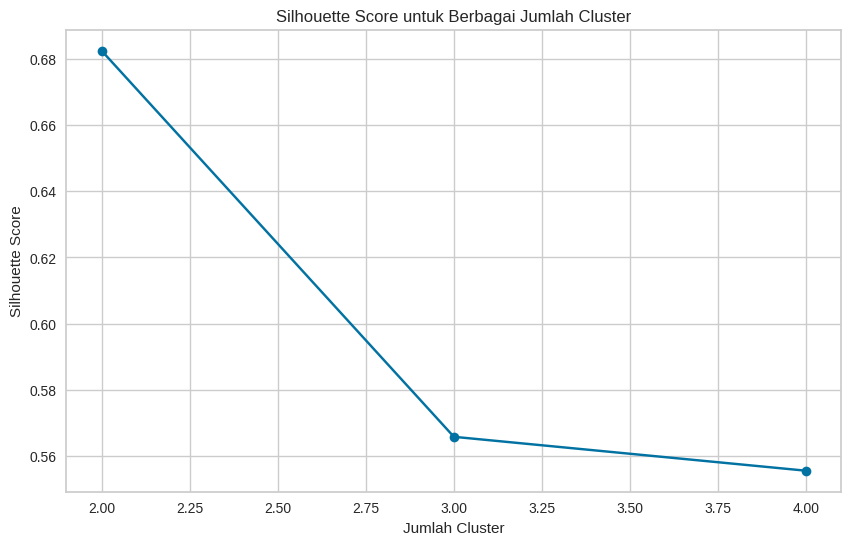


Menghitung nilai inertia untuk Elbow method...
Clusters: 2, Inertia: 399134.72
Clusters: 3, Inertia: 278454.85
Clusters: 4, Inertia: 223744.42
Clusters: 5, Inertia: 181053.41
Clusters: 6, Inertia: 149834.00
Clusters: 7, Inertia: 122775.39
Clusters: 8, Inertia: 109980.93
Clusters: 9, Inertia: 99124.40


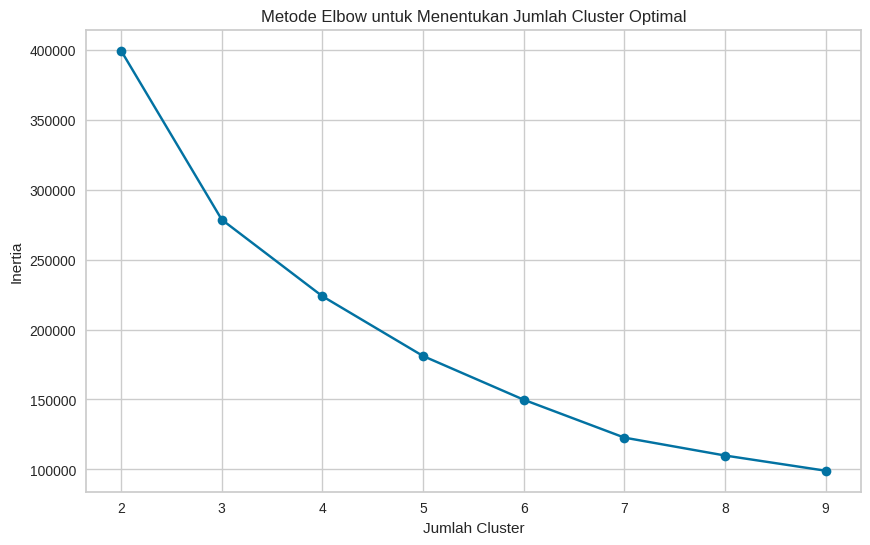


Generating Yellowbrick KElbowVisualizer...


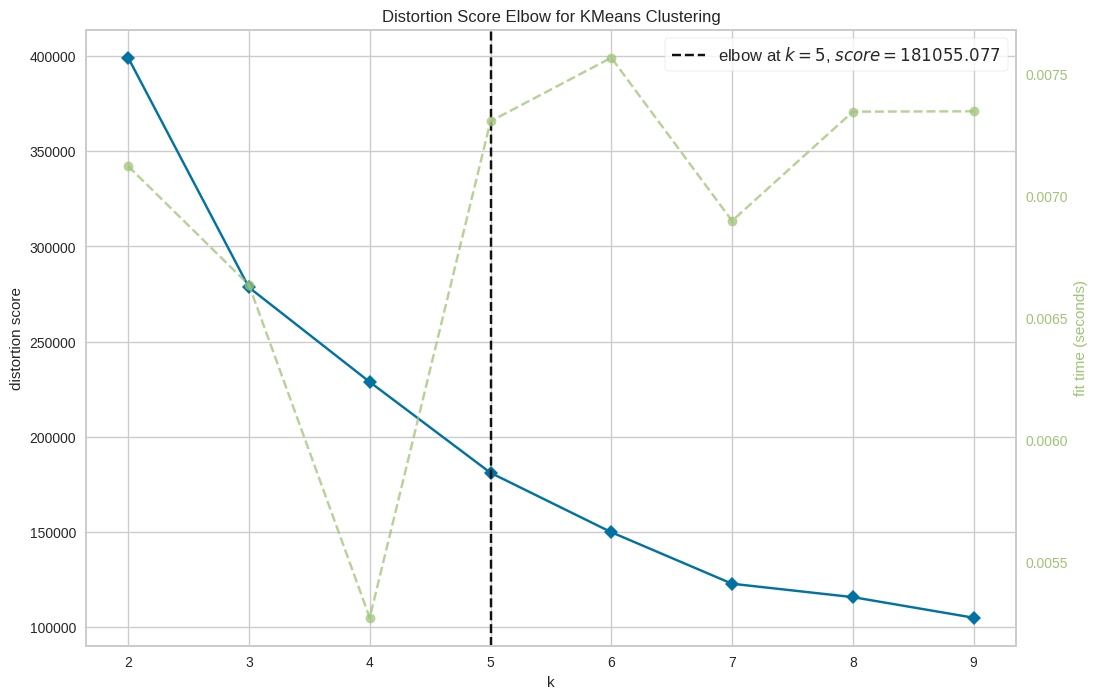

- Optimal clusters based on Silhouette Score: 2
- Optimal clusters based on Elbow Method: 3


In [9]:
print("Evaluasi cluster optimal...")

existing_range_n_clusters = range(2, 5)
expanded_range_n_clusters = range(2, 10)

# --- SILHOUETTE SCORE VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(existing_range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Berbagai Jumlah Cluster')
plt.grid(True)
plt.show()

print("\nMenghitung nilai inertia untuk Elbow method...")
inertia = []

if sample_size < len(X):
    X_for_inertia = X_sample
else:
    X_for_inertia = X

# Use the expanded range for inertia/elbow
for n_clusters in expanded_range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_for_inertia)
    inertia.append(kmeans.inertia_)
    print(f"Clusters: {n_clusters}, Inertia: {kmeans.inertia_:.2f}")

# --- MANUAL ELBOW METHOD PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(expanded_range_n_clusters, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal')
plt.grid(True)
plt.show()

# --- YELLOWBRICK ELBOW VISUALIZER ---
X_cluster = X_sample if sample_size < len(X) else X

print("\nGenerating Yellowbrick KElbowVisualizer...")
plt.figure(figsize=(12, 8))
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(X_cluster)
visualizer.show()

optimal_clusters_inertia = 0
max_improvement = 0

for i in range(1, len(inertia)-1):
    improvement = (inertia[i-1] - inertia[i]) / inertia[i-1]
    next_improvement = (inertia[i] - inertia[i+1]) / inertia[i]

    if improvement > next_improvement and improvement - next_improvement > max_improvement:
        max_improvement = improvement - next_improvement
        optimal_clusters_inertia = expanded_range_n_clusters[i]

print(f"- Optimal clusters based on Silhouette Score: {optimal_silhouette}")
print(f"- Optimal clusters based on Elbow Method: {optimal_clusters_inertia}")

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [10]:
y = cluster_labels
selector = SelectKBest(f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features_idx = selector.get_support(indices=True)
selected_features = X.columns[selected_features_idx]
X_selected = X[selected_features]

print("Fitur yang dipilih:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

param_grid = list(product(
    range(2, 11),  # n_clusters
    ['k-means++', 'random'],  # init
    [10, 20],  # n_init
    [300, 500]  # max_iter
))

best_score = -1
best_params = None
best_model = None
best_cluster_labels = None
all_results = []

print("\nMelakukan hyperparameter tuning (dengan sampling)...")
for i, (n_clusters, init, n_init, max_iter) in enumerate(param_grid, 1):
    model = KMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        random_state=42
    )


    cluster_labels_selected = model.fit_predict(X_selected)
    score = silhouette_score(X_selected, cluster_labels_selected, sample_size=500, random_state=42)
    all_results.append((score, n_clusters, init, n_init, max_iter))

    print(f"[{i}/{len(param_grid)}] n_clusters={n_clusters}, init={init}, n_init={n_init}, max_iter={max_iter} → Silhouette Score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = (n_clusters, init, n_init, max_iter)
        best_model = model
        best_cluster_labels = cluster_labels_selected

print("\nParameter terbaik berdasarkan Silhouette Score:")
print(f"n_clusters={best_params[0]}, init={best_params[1]}, n_init={best_params[2]}, max_iter={best_params[3]}")
print(f"Silhouette Score terbaik: {best_score:.4f}")

if best_score > max(silhouette_scores):
    print("\nModel dengan fitur terpilih dan hasil tuning lebih baik.")
    df_processed['Cluster'] = best_cluster_labels
    final_kmeans = best_model
    cluster_labels = best_cluster_labels
    optimal_n_clusters = best_params[0]
    X_used = X_selected
else:
    print("\n📉 Model hasil tuning tidak lebih baik dari model semua fitur.")
    X_used = X


Fitur yang dipilih:
1. Unit_Price
2. Quantity
3. Discount
4. Total_Price
5. Customer_Type_Encoded

Melakukan hyperparameter tuning (dengan sampling)...
[1/72] n_clusters=2, init=k-means++, n_init=10, max_iter=300 → Silhouette Score: 0.7351
[2/72] n_clusters=2, init=k-means++, n_init=10, max_iter=500 → Silhouette Score: 0.7351
[3/72] n_clusters=2, init=k-means++, n_init=20, max_iter=300 → Silhouette Score: 0.7351
[4/72] n_clusters=2, init=k-means++, n_init=20, max_iter=500 → Silhouette Score: 0.7351
[5/72] n_clusters=2, init=random, n_init=10, max_iter=300 → Silhouette Score: 0.7351
[6/72] n_clusters=2, init=random, n_init=10, max_iter=500 → Silhouette Score: 0.7351
[7/72] n_clusters=2, init=random, n_init=20, max_iter=300 → Silhouette Score: 0.7351
[8/72] n_clusters=2, init=random, n_init=20, max_iter=500 → Silhouette Score: 0.7351
[9/72] n_clusters=3, init=k-means++, n_init=10, max_iter=300 → Silhouette Score: 0.6631
[10/72] n_clusters=3, init=k-means++, n_init=10, max_iter=500 → Silh

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

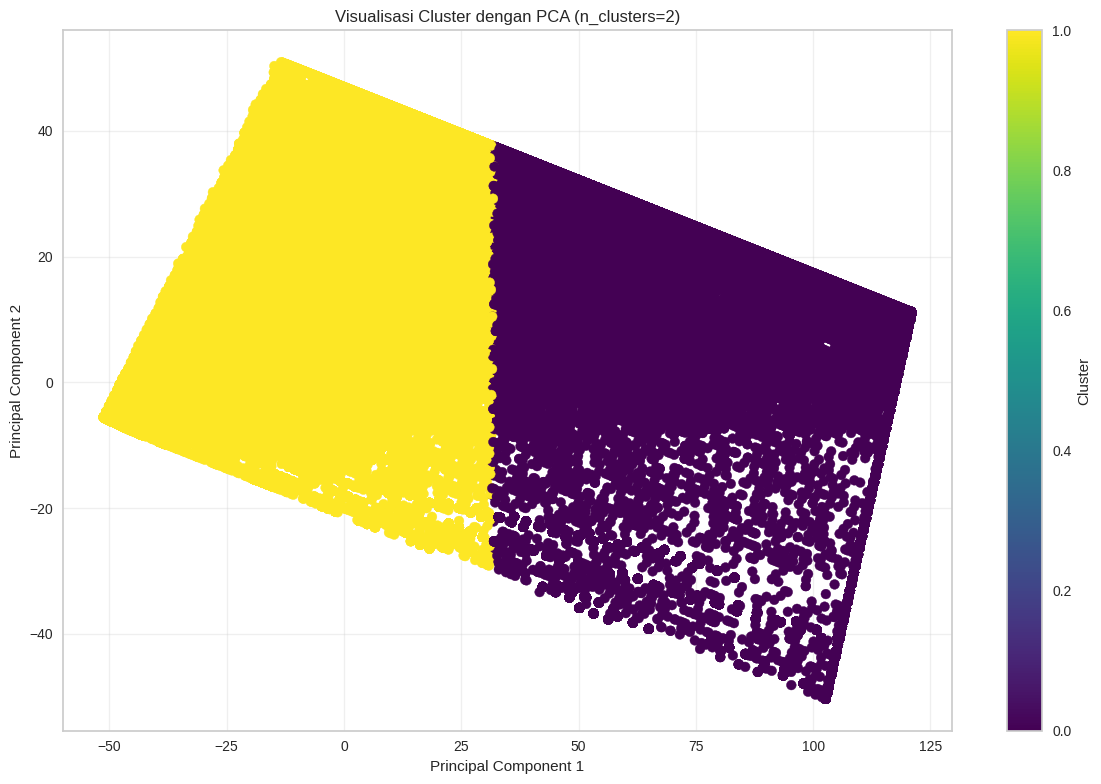

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


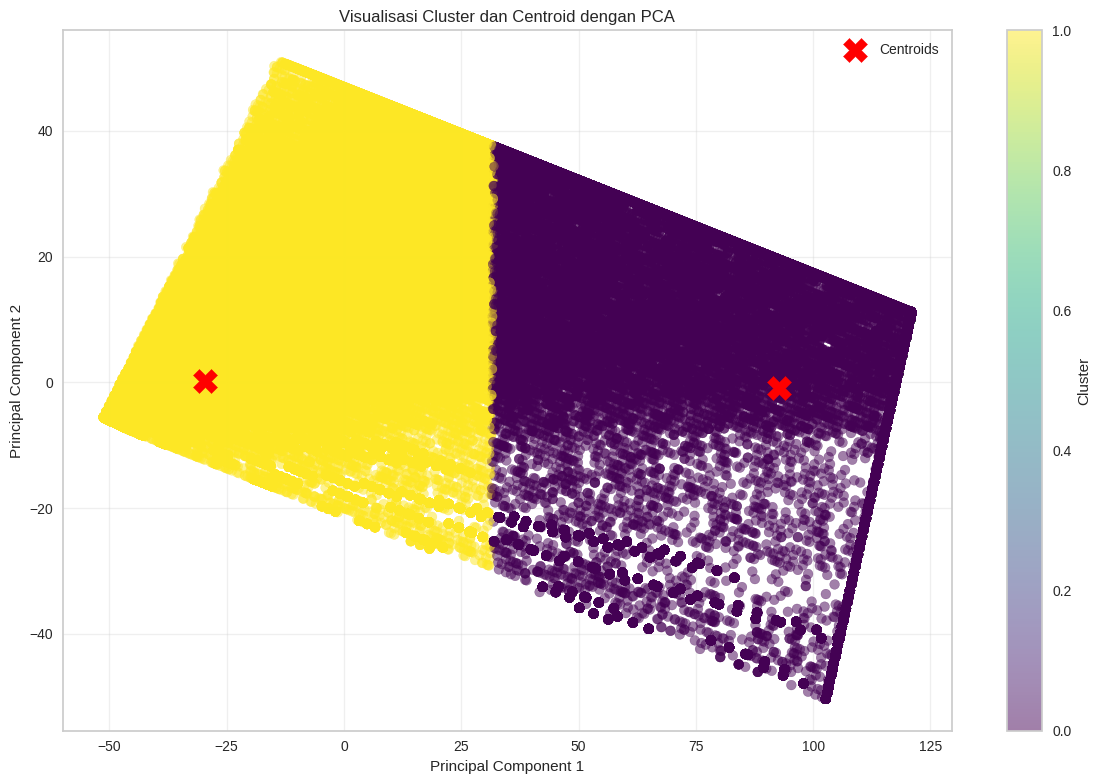

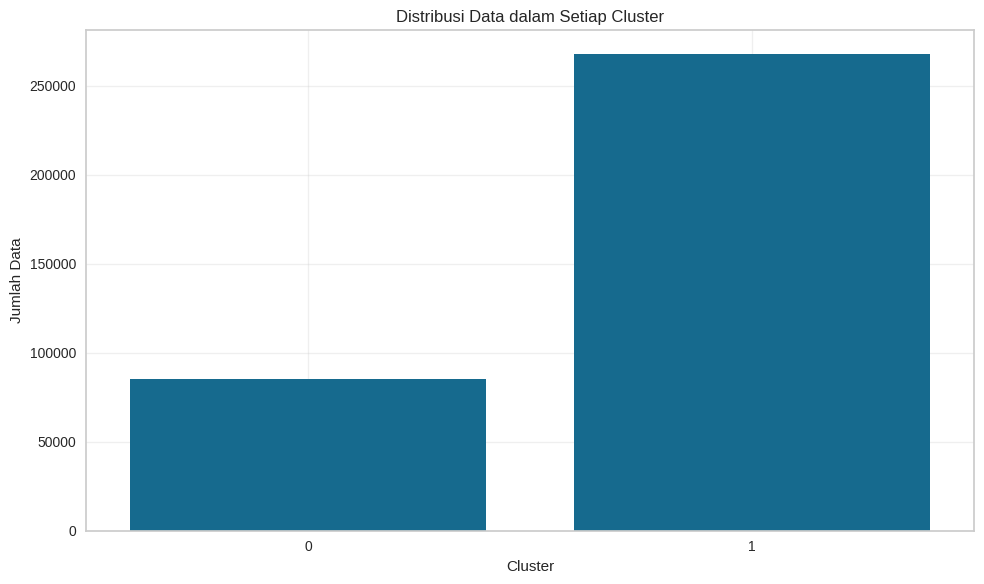

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_used)

# Membuat plot scatter
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=1)
plt.title(f'Visualisasi Cluster dengan PCA (n_clusters={optimal_n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisasi centroid
if len(X_used.columns) > 1:
    # Menerapkan PCA untuk mereduksi dimensi centroid
    centroids_pca = pca.transform(final_kmeans.cluster_centers_)

    # Plot centroid
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
    plt.title('Visualisasi Cluster dan Centroid dengan PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Distribusi cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=df_processed)
plt.title('Distribusi Data dalam Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

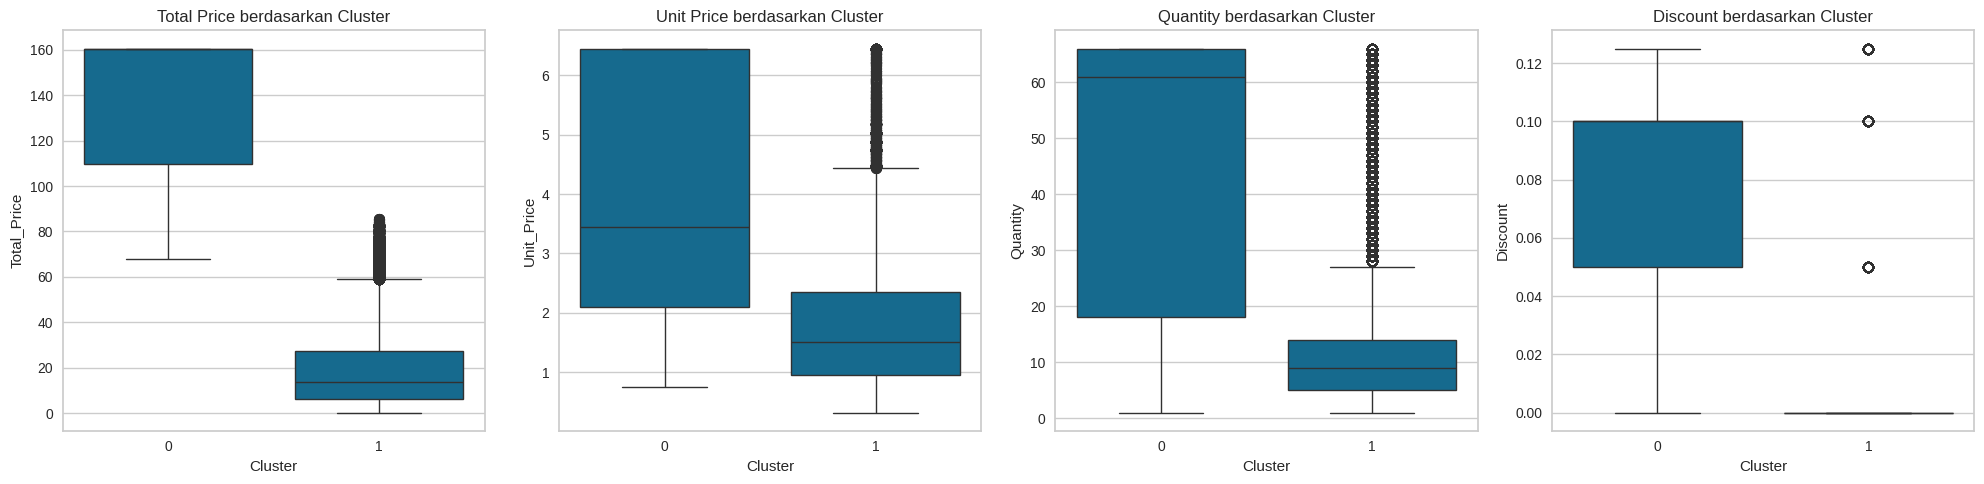

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


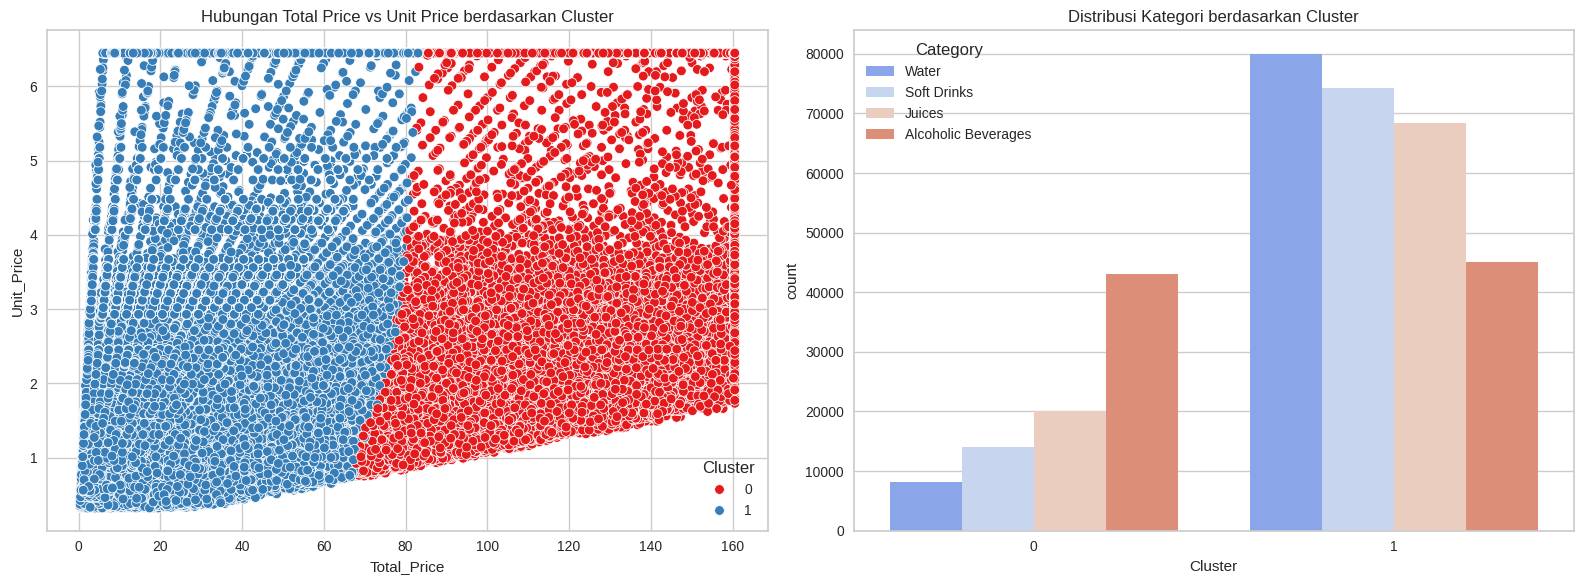

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Boxplot Total_Price
sns.boxplot(data=df_processed, x="Cluster", y="Total_Price", ax=axes[0])
axes[0].set_title("Total Price berdasarkan Cluster")

# Boxplot Unit_Price
sns.boxplot(data=df_processed, x="Cluster", y="Unit_Price", ax=axes[1])
axes[1].set_title("Unit Price berdasarkan Cluster")

# Boxplot Quantity
sns.boxplot(data=df_processed, x="Cluster", y="Quantity", ax=axes[2])
axes[2].set_title("Quantity berdasarkan Cluster")

# Boxplot Discount
sns.boxplot(data=df_processed, x="Cluster", y="Discount", ax=axes[3])
axes[3].set_title("Discount berdasarkan Cluster")

# Atur layout agar tidak saling tumpang tindih
plt.tight_layout()
plt.show()

# Buat figure dengan 1 row dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot: Hubungan Total_Price vs Unit_Price berdasarkan Cluster
sns.scatterplot(data=df_processed, x="Total_Price", y="Unit_Price", hue="Cluster", palette="Set1", ax=axes[0])
axes[0].set_title("Hubungan Total Price vs Unit Price berdasarkan Cluster")

# Countplot: Distribusi Kategori berdasarkan Cluster
sns.countplot(data=df_processed, x="Cluster", hue="Category", palette="coolwarm", ax=axes[1])
axes[1].set_title("Distribusi Kategori berdasarkan Cluster")

# Tampilkan plot
plt.tight_layout()
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

    ### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [21]:
for col in categorical_cols:
    encoded_col_name = f"{col}_Encoded"

    if encoded_col_name in df_processed.columns and col in label_encoders:
        print(f"Inverse transforming kolom: '{encoded_col_name}' -> '{col}'")

        encoder = label_encoders[col]

        df_processed[col] = encoder.inverse_transform(df_processed[encoded_col_name])

        df_processed.drop(columns=[encoded_col_name], inplace=True)

    else:
        if encoded_col_name not in df_processed.columns:
            print(f" Kolom encoded '{encoded_col_name}' tidak ditemukan dalam df_processed.")
        if col not in label_encoders:
            print(f" Encoder untuk kolom '{col}' tidak ditemukan dalam label_encoders.")

 Kolom encoded 'Customer_Type_Encoded' tidak ditemukan dalam df_processed.
 Kolom encoded 'Product_Encoded' tidak ditemukan dalam df_processed.
 Kolom encoded 'Category_Encoded' tidak ditemukan dalam df_processed.


# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0:
- Total_Price, Unit_Price, dan Quantity memiliki nilai lebih tinggi.
- Indikasi bahwa pelanggan dalam cluster ini membeli produk dalam jumlah besar dan/atau produk dengan harga tinggi.
- Kemungkinan besar terkait dengan produk premium seperti Water atau Alcoholic Beverages.

## Cluster 1:
- Memiliki Total_Price, Unit_Price, dan Quantity yang lebih rendah.
- Pelanggan dalam cluster ini kemungkinan membeli produk lebih murah dan dalam jumlah kecil.
- Kemungkinan besar berkaitan dengan Juices dan Soft Drinks.

# Insight Bisnis Berdasarkan Dua Cluster:

## Strategi Pemasaran Tersegmentasi

Cluster 0 (Produk Premium - Water & Alcoholic Beverages)

- Terapkan strategi eksklusif, seperti :

    - Loyalty Program
    - Packaging premium sebagai kampanye branding

Cluster 1 (Produk Murah - Juices & Soft Drinks):

- Fokus pada promosi berbasis volume, seperti:

    - Diskon untuk pembelian dalam jumlah besar
    - Program diskon

## Segmentas Harga dan Promosi

- Produk dengan Unit_Price tinggi → dijual dengan pendekatan premium branding.

- Produk dengan Total_Price tinggi → targetkan pelanggan tetap dengan penawaran loyalitas.

## Optimasi Ketersediaan Stok

- Cluster 0 menunjukkan quantity tinggi → pastikan ada stok yang memadai agar tidak kehabisan.

- Cluster 1 quantity rendah → bisa lebih fleksibel dalam pengelolaan stok.

## Kesimpulan

- Pelaku Bisnis dapat menggunakan insight ini untuk strategi promosi yang lebih efektif berdasarkan karakteristik masing-masing cluster.

- Perlu dilakukan validasi lebih lanjut terkait dengan data untuk memastikan keakuratan segmentasi pelanggan


# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [22]:
df_processed.to_csv('data_clustering_final.csv', index=False)